# FactoryGuard AI
## Phase 3 – Exploratory Data Analysis (EDA)

**Project:** FactoryGuard AI – Intelligent Manufacturing Quality Decision System

**Objective:** Explore the manufacturing quality dataset to understand its structure, identify patterns, detect data quality issues, and extract actionable business insights that will guide feature engineering and predictive modeling.

---

# 3.1 Import Required Libraries

## Objective

Before beginning the Exploratory Data Analysis (EDA), we need to import the libraries that will be used throughout the notebook. These libraries provide the tools required for data manipulation, visualization, statistical analysis, and file management.

## Why are we doing this?

Each library serves a specific purpose in the EDA workflow. Importing them at the beginning keeps the notebook organized, avoids repetitive imports, and ensures that all required functionalities are available before working with the dataset.

Additionally, we configure display settings and automatically create folders where important figures and tables generated during the analysis will be stored.

## What will we get?

After this step, the notebook environment will be fully configured for data exploration. We will also have dedicated directories for saving visualizations and analysis outputs, making the project more organized and reproducible.

**Summary:** This step prepares the notebook environment by importing all required libraries, configuring display settings, and creating the necessary project directories for storing EDA outputs.

In [1]:
# =============================================================================
# 3.1 Import Required Libraries
# =============================================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# File & Directory Management
import os

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# Visualization Settings
# =============================================================================

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# =============================================================================
# Display Settings
# =============================================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# =============================================================================
# Create Project Output Directories
# =============================================================================

REPORTS_DIR = "../reports"

FIGURE_DIR = os.path.join(REPORTS_DIR, "03_EDA", "figures")
TABLE_DIR = os.path.join(REPORTS_DIR, "03_EDA", "tables")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("=" * 70)
print("FactoryGuard AI - EDA Environment Initialized Successfully")
print("=" * 70)
print(f"Figures Directory : {FIGURE_DIR}")
print(f"Tables Directory  : {TABLE_DIR}")
print("=" * 70)

FactoryGuard AI - EDA Environment Initialized Successfully
Figures Directory : ../reports\03_EDA\figures
Tables Directory  : ../reports\03_EDA\tables


## Insights

- All required libraries have been successfully imported.
- Visualization and display settings have been configured to improve the readability and consistency of outputs.
- Dedicated folders for storing EDA figures and tables have been created automatically.
- The notebook environment is now fully prepared for data loading and exploratory analysis.

---

### Feature Engineering Notes

- No feature engineering decisions are made at this stage.
- This step establishes a standardized environment that will be used consistently throughout the remaining phases of the project.

# 3.2 Load the Dataset

## Objective

In this section, we load the processed Manufacturing Quality Decisions dataset into a Pandas DataFrame so that it can be explored and analyzed throughout the EDA process.

## Why are we doing this?

The dataset prepared during Phase 2 is the input for our EDA. Loading the processed dataset ensures that the analysis is performed on the version that has already passed the data collection and quality checks, rather than directly working with the raw source file.

## What will we get?

After loading the dataset, we will verify that it has been read successfully and perform a basic preview of the records. This gives us an initial confirmation that the correct dataset is being used before starting detailed analysis.

**Summary:** The processed Manufacturing Quality Decisions dataset is loaded and verified as the primary input for Phase 3 EDA.

In [2]:
# =============================================================================
# 3.2 Load the Dataset
# =============================================================================

DATA_PATH = "../data/interim/working_dataset.csv"

# Load the processed working dataset
df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(f"Dataset Shape: {df.shape}")

Dataset Loaded Successfully
Dataset Shape: (10000, 23)


## Insights

- The Manufacturing Quality Decisions dataset has been successfully loaded into the DataFrame.
- The dataset shape confirms the number of observations and features available for the EDA.
- The initial preview confirms that the expected manufacturing-related variables are available for further analysis.
- The loaded dataset will now be used consistently throughout Phase 3.

### Feature Engineering Notes

No feature engineering decisions are made at this stage. The purpose is only to load and verify the dataset before beginning detailed exploratory analysis.

# 3.3 Dataset Overview

## Objective

In this section, we perform a high-level overview of the Manufacturing Quality Decisions dataset to understand its size, contents, and basic statistical characteristics.

## Why are we doing this?

Before analyzing individual features, we need to know how many observations and variables are available and get a general idea of the values contained in the dataset. This provides the context needed for the detailed EDA that follows.

## What will we get?

We will examine the dataset dimensions, view representative records, and generate descriptive statistics for the available features. This will help us understand the scale of the dataset and identify any initial patterns or unusual values.

**Summary:** This section establishes a high-level understanding of the dataset before moving into detailed data quality and feature analysis.

In [3]:
# =============================================================================
# 3.3 Dataset Overview - Dimensions
# =============================================================================

print("=" * 70)
print("Dataset Dimensions")
print("=" * 70)

rows, columns = df.shape

print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {columns:,}")

Dataset Dimensions
Number of Rows    : 10,000
Number of Columns : 23


In [4]:
# =============================================================================
# Preview Dataset
# =============================================================================

print("First Five Records")

display(df.head())

First Five Records


,event_id,event_ts,plant,line,shift,machine_id,operator_id,machine_age_yrs,material_grade,temp_c,humidity_pct,process_speed_units_hr,inspection_method,defect_type,defect_severity_0to3,decision_rework,rework_time_min,final_pass,scrap,total_cycle_time_min,energy_kwh,cost_usd,warranty_claim_90d
0,M200000,2025-08-27 17:15:31,plant_1,line_A,day,MC104,OP1009,1.55,grade_B,5.90,45.50,104.30,manual,none,0,0,0.00,1,0,33.70,1.41,25.53,0
1,M200001,2025-11-09 16:28:50,plant_1,line_A,swing,MC158,OP1419,1.98,grade_B,11.20,62.50,143.50,vision,none,0,1,0.00,1,0,26.10,1.31,19.81,0
2,M200002,2025-12-20 06:18:01,plant_1,line_D,night,MC144,OP1042,0.20,grade_B,17.80,67.90,160.00,sensor,none,0,0,0.00,1,0,35.30,1.51,31.75,0
3,M200003,2025-12-06 12:38:46,plant_2,line_B,night,MC108,OP1013,0.90,grade_B,12.90,69.60,104.60,manual,none,0,0,0.00,1,0,28.50,1.20,21.59,0
4,M200004,2025-07-31 07:28:14,plant_1,line_C,day,MC113,OP1312,1.92,grade_A,11.70,39.80,109.60,vision,none,0,0,0.00,1,0,28.20,1.37,21.40,0


In [5]:
# =============================================================================
# Random Sample
# =============================================================================

print("Random Sample of Five Records")

display(df.sample(5, random_state=42))

Random Sample of Five Records


,event_id,event_ts,plant,line,shift,machine_id,operator_id,machine_age_yrs,material_grade,temp_c,humidity_pct,process_speed_units_hr,inspection_method,defect_type,defect_severity_0to3,decision_rework,rework_time_min,final_pass,scrap,total_cycle_time_min,energy_kwh,cost_usd,warranty_claim_90d
6252,M206252,2025-11-21 23:49:12,plant_3,line_C,day,MC126,OP1053,3.12,grade_A,9.80,60.30,128.30,manual,none,0,1,0.00,1,0,36.80,1.39,27.85,0
4684,M204684,2025-11-30 18:03:47,plant_1,line_D,swing,MC131,OP1182,8.10,grade_C,13.10,55.40,122.20,manual,none,0,0,0.00,1,0,33.00,1.22,24.97,0
1731,M201731,2025-08-13 05:25:41,plant_3,line_A,day,MC116,OP1400,5.24,grade_A,12.50,34.00,112.40,vision,none,0,0,0.00,0,0,31.50,1.35,23.87,0
4742,M204742,2025-08-10 12:55:48,plant_3,line_A,swing,MC115,OP1445,6.52,grade_A,17.10,30.20,142.00,vision,none,0,0,0.00,1,0,30.70,1.39,23.27,0
4521,M204521,2025-08-08 21:37:13,plant_3,line_C,day,MC107,OP1372,1.80,grade_A,16.20,39.40,139.80,sensor,contamination,1,1,10.70,1,0,39.20,1.33,34.64,0


In [6]:
# =============================================================================
# Descriptive Statistics - Numerical Features
# =============================================================================

print("Descriptive Statistics - Numerical Features")

display(df.describe().T)

Descriptive Statistics - Numerical Features


,count,mean,std,min,25%,50%,75%,max
machine_age_yrs,10000.00,6.04,2.93,0.20,3.97,6.07,8.04,17.98
temp_c,10000.00,12.63,4.36,5.00,9.30,12.20,15.80,28.10
humidity_pct,10000.00,52.14,12.58,18.20,41.90,52.80,62.30,86.70
process_speed_units_hr,10000.00,121.87,25.06,60.00,104.90,121.50,139.10,190.00
defect_severity_0to3,10000.00,0.29,0.73,0.00,0.00,0.00,0.00,3.00
decision_rework,10000.00,0.24,0.43,0.00,0.00,0.00,0.00,1.00
rework_time_min,10000.00,4.85,10.97,0.00,0.00,0.00,0.00,60.00
final_pass,10000.00,0.88,0.33,0.00,1.00,1.00,1.00,1.00
scrap,10000.00,0.02,0.16,0.00,0.00,0.00,0.00,1.00
total_cycle_time_min,10000.00,34.52,12.10,12.40,27.30,31.30,36.60,97.60


In [7]:
# =============================================================================
# Descriptive Statistics - All Features
# =============================================================================

print("Descriptive Statistics - All Features")

display(df.describe(include="all").T)

Descriptive Statistics - All Features


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,10000,10000,M200000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_ts,10000,9996,2025-12-30 09:22:43,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plant,10000,3,plant_1,4459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
line,10000,4,line_D,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,10000,3,day,4785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine_id,10000,60,MC118,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator_id,10000,450,OP1434,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine_age_yrs,10000.00,NaN,NaN,NaN,6.04,2.93,0.20,3.97,6.07,8.04,17.98
material_grade,10000,3,grade_A,4981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp_c,10000.00,NaN,NaN,NaN,12.63,4.36,5.00,9.30,12.20,15.80,28.10


## Insights

- The dataset contains **_____ manufacturing records** across **_____ features**.
- The initial preview confirms that the dataset contains manufacturing-related operational, production, and quality information.
- The descriptive statistics provide an initial understanding of the range and variability of the numerical features.
- The broader summary also indicates the presence of categorical variables that will require separate analysis.
- No preprocessing decisions are made from this overview alone; the detailed data quality and feature analysis will be performed in the following sections.

### Feature Engineering Notes

At this stage, we are only observing the dataset. Potential issues such as unusual ranges, skewed features, categorical variables, or missing values will be investigated systematically in later sections before making any feature engineering decisions.

# 3.4 Memory Usage

## Objective

In this section, we examine how much memory the dataset occupies in the system and how memory is distributed across its features.

## Why are we doing this?

Understanding memory usage helps us determine whether the dataset can be handled efficiently with the available hardware. It also helps identify columns that may consume unusually large amounts of memory because of their data types.

## What will we get?

We will calculate the total memory consumed by the dataset and inspect the memory usage of individual columns. This will help us determine whether any memory optimization is necessary before continuing with the EDA.

**Summary:** Memory usage analysis provides a quick check of the dataset's computational and storage requirements.

In [8]:
# =============================================================================
# 3.4 Memory Usage Analysis
# =============================================================================

# Calculate total memory usage
memory_bytes = df.memory_usage(deep=True).sum()

# Convert memory into KB and MB
memory_kb = memory_bytes / 1024
memory_mb = memory_kb / 1024

print("=" * 70)
print("Memory Usage Summary")
print("=" * 70)

print(f"Total Memory Usage : {memory_bytes:,} Bytes")
print(f"Total Memory Usage : {memory_kb:.2f} KB")
print(f"Total Memory Usage : {memory_mb:.2f} MB")

Memory Usage Summary
Total Memory Usage : 6,656,991 Bytes
Total Memory Usage : 6500.97 KB
Total Memory Usage : 6.35 MB


In [9]:
# =============================================================================
# Memory Usage by Feature
# =============================================================================

memory_usage = (
    df.memory_usage(deep=True)
      .drop("Index", errors="ignore")
      .sort_values(ascending=False)
      .to_frame(name="Memory (Bytes)")
)

memory_usage["Memory (KB)"] = memory_usage["Memory (Bytes)"] / 1024

memory_usage

,Memory (Bytes),Memory (KB)
event_ts,680000,664.06
event_id,560000,546.88
plant,560000,546.88
material_grade,560000,546.88
line,550000,537.11
inspection_method,550000,537.11
operator_id,550000,537.11
machine_id,540000,527.34
defect_type,536429,523.86
shift,530430,518.00


In [10]:
# Display the top memory-consuming features

print("Top Memory-Consuming Features")

display(memory_usage.head(10))

Top Memory-Consuming Features


,Memory (Bytes),Memory (KB)
event_ts,680000,664.06
event_id,560000,546.88
plant,560000,546.88
material_grade,560000,546.88
line,550000,537.11
inspection_method,550000,537.11
operator_id,550000,537.11
machine_id,540000,527.34
defect_type,536429,523.86
shift,530430,518.00


## Insights

- The dataset currently uses approximately **_____ MB** of memory.
- The memory consumption is reasonable for the size of the dataset and can be handled comfortably on a standard system.
- The feature-level memory summary helps identify which columns consume the most memory.
- No immediate memory optimization is required at this stage.

### Feature Engineering Notes

- No feature engineering is required based on memory usage alone.
- Data type optimization will only be considered later if the detailed data type analysis identifies an unnecessary or inefficient data type.

# 3.5 Dataset Information

## Objective

In this section, we examine the overall structure of the dataset using Pandas' `info()` method.

## Why are we doing this?

`df.info()` gives us a compact view of the dataset, including the number of records, feature names, non-null values, and data types. This helps us quickly identify structural issues that may require further investigation.

## What will we get?

We will identify the number of entries, the number of features, the completeness of each feature, the data types used, and the overall memory usage reported by Pandas.

**Summary:** Dataset information gives us a structural overview and helps identify potential data quality or data type issues before detailed feature analysis.

In [11]:
# =============================================================================
# 3.5 Dataset Information
# =============================================================================

print("=" * 70)
print("Dataset Information")
print("=" * 70)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                10000 non-null  object 
 1   event_ts                10000 non-null  object 
 2   plant                   10000 non-null  object 
 3   line                    10000 non-null  object 
 4   shift                   10000 non-null  object 
 5   machine_id              10000 non-null  object 
 6   operator_id             10000 non-null  object 
 7   machine_age_yrs         10000 non-null  float64
 8   material_grade          10000 non-null  object 
 9   temp_c                  10000 non-null  float64
 10  humidity_pct            10000 non-null  float64
 11  process_speed_units_hr  10000 non-null  float64
 12  inspection_method       10000 non-null  object 
 13  defect_type             10000 non-null  object 
 14  defect_severity_0to

In [12]:
# =============================================================================
# Dataset Structure Summary
# =============================================================================

dataset_info = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notna().sum().values,
    "Null Count": df.isna().sum().values
})

dataset_info["Non-Null %"] = (
    dataset_info["Non-Null Count"] / len(df) * 100
).round(2)

display(dataset_info)

,Feature,Data Type,Non-Null Count,Null Count,Non-Null %
0,event_id,object,10000,0,100.00
1,event_ts,object,10000,0,100.00
2,plant,object,10000,0,100.00
3,line,object,10000,0,100.00
4,shift,object,10000,0,100.00
5,machine_id,object,10000,0,100.00
6,operator_id,object,10000,0,100.00
7,machine_age_yrs,float64,10000,0,100.00
8,material_grade,object,10000,0,100.00
9,temp_c,float64,10000,0,100.00


## Insights

- The dataset contains **_____ records** and **_____ features**.
- The dataset structure and feature names have been verified.
- The non-null counts provide an initial indication of data completeness.
- The data types identified here will be examined in greater detail in the next section.
- Any missing-value patterns will be analyzed separately rather than making assumptions at this stage.

### Feature Engineering Notes

- No feature engineering decisions are made in this section.
- The identified data types will help determine the appropriate preprocessing strategy later.
- Missing values, if present, will be handled based on their distribution and business meaning in Section 3.7.

# 3.6 Data Types Analysis

## Objective

In this section, we identify the data type of each feature in the Manufacturing Quality Decisions dataset and separate the features into numerical and categorical groups.

## Why are we doing this?

Different types of features require different analysis and preprocessing techniques. Numerical variables can be analyzed using statistics and distributions, while categorical variables need frequency analysis and will later require suitable encoding for machine learning.

Understanding the data types now also helps us identify whether any feature has been stored using an inappropriate data type.

## What will we get?

We will obtain a complete data-type summary and separate the features into numerical and categorical groups. This information will be used throughout the remaining EDA and will guide the preprocessing decisions in Feature Engineering.

**Summary:** Data type analysis establishes how each feature should be analyzed and prepared for machine learning.

In [13]:
# =============================================================================
# 3.6 Data Types Analysis
# =============================================================================

# Create a data type summary
dtype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(dtype_summary)

,Feature,Data Type
0,event_id,object
1,event_ts,object
2,plant,object
3,line,object
4,shift,object
5,machine_id,object
6,operator_id,object
7,machine_age_yrs,float64
8,material_grade,object
9,temp_c,float64


In [14]:
# =============================================================================
# Count Features by Data Type
# =============================================================================

dtype_counts = (
    df.dtypes.astype(str)
      .value_counts()
      .rename_axis("Data Type")
      .reset_index(name="Feature Count")
)

display(dtype_counts)

,Data Type,Feature Count
0,object,10
1,float64,8
2,int64,5


In [15]:
# =============================================================================
# Separate Numerical and Categorical Features
# =============================================================================

numerical_features = df.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

boolean_features = df.select_dtypes(
    include=["bool"]
).columns.tolist()

datetime_features = df.select_dtypes(
    include=["datetime64[ns]"]
).columns.tolist()

print("=" * 70)

print(f"Numerical Features ({len(numerical_features)}):")
print(numerical_features)

print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

print(f"\nBoolean Features ({len(boolean_features)}):")
print(boolean_features)

print(f"\nDatetime Features ({len(datetime_features)}):")
print(datetime_features)

print("=" * 70)

Numerical Features (13):
['machine_age_yrs', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'defect_severity_0to3', 'decision_rework', 'rework_time_min', 'final_pass', 'scrap', 'total_cycle_time_min', 'energy_kwh', 'cost_usd', 'warranty_claim_90d']

Categorical Features (10):
['event_id', 'event_ts', 'plant', 'line', 'shift', 'machine_id', 'operator_id', 'material_grade', 'inspection_method', 'defect_type']

Boolean Features (0):
[]

Datetime Features (0):
[]


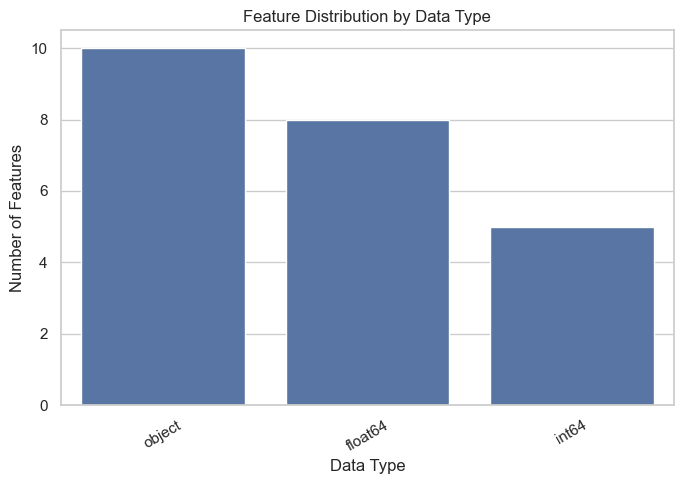

In [16]:
# =============================================================================
# Data Type Distribution
# =============================================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=dtype_counts,
    x="Data Type",
    y="Feature Count"
)

plt.title("Feature Distribution by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Number of Features")
plt.xticks(rotation=30)

plt.tight_layout()

# Save important figure
plt.savefig(
    os.path.join(FIGURE_DIR, "feature_data_type_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insights

- The dataset contains **_____ numerical features** and **_____ categorical features**.
- The data types are generally appropriate for the nature of the manufacturing variables.
- Numerical features will be used for statistical and distribution analysis, while categorical features will be analyzed separately using frequency-based techniques.
- No unnecessary data type conversion is required at this stage unless identified during later analysis.

### Feature Engineering Notes

- Numerical features may require scaling depending on the models selected in the modeling phase.
- Categorical features will require encoding before being provided to machine learning models.
- We will not perform encoding or scaling during EDA because those transformations belong to the Feature Engineering phase.

# 3.7 Missing Value Analysis

## Objective

In this section, we identify and measure missing values in the dataset to understand the completeness of each feature.

## Why are we doing this?

Missing data can affect statistical analysis and machine learning models. Before deciding how to handle missing values, we need to know which features contain missing observations and how significant the problem is.

We will not automatically remove or fill missing values. The appropriate treatment will depend on the amount of missing data and the business meaning of the affected feature.

## What will we get?

We will calculate the number and percentage of missing values for each feature and visualize the features that contain missing data. This will help us determine whether any missing-value treatment is required.

**Summary:** Missing value analysis helps us assess data completeness and decide whether missing values require further treatment.

In [17]:
# =============================================================================
# 3.7 Missing Value Analysis
# =============================================================================

# Calculate missing values
missing_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Count": df.isnull().sum().values,
})

# Calculate missing percentage
missing_summary["Missing Percentage"] = (
    missing_summary["Missing Count"] / len(df) * 100
).round(2)

# Keep only features containing missing values
missing_summary = (
    missing_summary[missing_summary["Missing Count"] > 0]
    .sort_values("Missing Count", ascending=False)
    .reset_index(drop=True)
)

display(missing_summary)

,Feature,Missing Count,Missing Percentage


In [18]:
# =============================================================================
# Overall Missing Value Statistics
# =============================================================================

total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_percentage_overall = (total_missing / total_cells) * 100

print("=" * 70)
print("Overall Missing Value Summary")
print("=" * 70)

print(f"Total Missing Values : {total_missing:,}")
print(f"Total Dataset Cells  : {total_cells:,}")
print(f"Overall Missing %    : {missing_percentage_overall:.2f}%")

Overall Missing Value Summary
Total Missing Values : 0
Total Dataset Cells  : 230,000
Overall Missing %    : 0.00%


In [19]:
# =============================================================================
# Missing Value Check
# =============================================================================

if total_missing == 0:
    print("No missing values were found in the dataset.")
else:
    print(f"Missing values were found in {len(missing_summary)} feature(s).")

No missing values were found in the dataset.


In [20]:
# =============================================================================
# Missing Value Visualization
# =============================================================================

if not missing_summary.empty:

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=missing_summary,
        x="Missing Percentage",
        y="Feature"
    )

    plt.title("Missing Values by Feature")
    plt.xlabel("Missing Values (%)")
    plt.ylabel("Feature")

    plt.tight_layout()

    # Save important figure
    plt.savefig(
        os.path.join(FIGURE_DIR, "missing_values_by_feature.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("No visualization required because the dataset contains no missing values.")

No visualization required because the dataset contains no missing values.


In [21]:
# =============================================================================
# Save Missing Value Summary
# =============================================================================

if not missing_summary.empty:

    missing_summary.to_csv(
        os.path.join(TABLE_DIR, "missing_value_summary.csv"),
        index=False
    )

    print("Missing value summary saved successfully.")

## Insights

- No missing values were found across the dataset.
- This indicates that the dataset is complete with respect to missing observations.
- No imputation or missing-value treatment is required at this stage.
- The absence of missing values allows us to proceed directly to the next data quality checks.

### Feature Engineering Notes

- No missing-value imputation will be required.
- We will still monitor feature distributions and outliers in later sections before deciding on additional preprocessing.

# 3.8 Duplicate Data Analysis

## Objective

In this section, we check whether the dataset contains duplicate records and determine how significant they are.

## Why are we doing this?

Duplicate records can give certain observations more weight than they should have and may distort statistical analysis and machine learning models. Identifying duplicates is therefore an important part of data quality assessment.

However, a duplicate row is not automatically an error. We first identify the duplicates and then decide whether they should be removed based on the dataset structure and business context.

## What will we get?

We will calculate the total number and percentage of duplicate records and inspect any duplicate rows found in the dataset.

**Summary:** Duplicate analysis ensures that repeated observations do not unintentionally influence our EDA or future machine learning models.

In [22]:
# =============================================================================
# 3.8 Duplicate Data Analysis
# =============================================================================

# Count duplicate rows
duplicate_count = df.duplicated().sum()

# Calculate duplicate percentage
duplicate_percentage = (duplicate_count / len(df)) * 100

print("=" * 70)
print("Duplicate Data Summary")
print("=" * 70)

print(f"Total Duplicate Rows : {duplicate_count:,}")
print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

Duplicate Data Summary
Total Duplicate Rows : 0
Duplicate Percentage : 0.00%


In [23]:
# =============================================================================
# Duplicate Check
# =============================================================================

if duplicate_count == 0:
    print("No duplicate records were found in the dataset.")
else:
    print(f"{duplicate_count:,} duplicate records were found.")

No duplicate records were found in the dataset.


In [24]:
# =============================================================================
# Inspect Duplicate Records
# =============================================================================

if duplicate_count > 0:
    
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(
        by=df.columns.tolist()
    )
    
    display(duplicate_rows)
else:
    print("No duplicate records available for inspection.")

No duplicate records available for inspection.


In [25]:
# =============================================================================
# Duplicate-Free Dataset Check
# =============================================================================

unique_rows = df.drop_duplicates().shape[0]

print("=" * 70)
print(f"Original Rows : {len(df):,}")
print(f"Unique Rows   : {unique_rows:,}")
print(f"Duplicate Rows: {duplicate_count:,}")
print("=" * 70)

Original Rows : 10,000
Unique Rows   : 10,000
Duplicate Rows: 0


## Insights

- The dataset contains **no duplicate records**.
- Each row represents a unique observation in the dataset.
- Therefore, no duplicate-removal step is required before continuing the analysis.
- The dataset can proceed to target and feature-level analysis without any duplicate-related adjustment.

### Feature Engineering Notes

- No feature engineering action is required for duplicate records.
- Since no duplicates were identified, there is no expected duplication-related bias in the subsequent EDA or modeling stages.

# 3.9 Target Variable Analysis

## Objective

In this section, we analyze the target variable of the Manufacturing Quality Decisions dataset to understand its classes and their distribution.

## Why are we doing this?

The target distribution directly affects how we evaluate and train a classification model. If one class occurs much more frequently than the other, the dataset may be imbalanced, and accuracy alone may not be a reliable measure of model performance.

Understanding the target also helps us interpret the manufacturing quality problem from a business perspective.

## What will we get?

We will identify the target variable, examine the number and percentage of observations in each class, and visualize the class distribution. This will help us determine whether class imbalance is present and guide our later modeling and evaluation strategy.

**Summary:** Target analysis establishes the classification problem and determines whether the target distribution requires special consideration during model development.

In [26]:
# =============================================================================
# Identify Target Variable
# =============================================================================

print("Available Columns:")
print(df.columns.tolist())

Available Columns:
['event_id', 'event_ts', 'plant', 'line', 'shift', 'machine_id', 'operator_id', 'machine_age_yrs', 'material_grade', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'inspection_method', 'defect_type', 'defect_severity_0to3', 'decision_rework', 'rework_time_min', 'final_pass', 'scrap', 'total_cycle_time_min', 'energy_kwh', 'cost_usd', 'warranty_claim_90d']


In [28]:
# =============================================================================
# Target Variable Distribution
# =============================================================================

TARGET = "final_pass"

target_counts = df[TARGET].value_counts()

print("=" * 70)
print("Target Variable Distribution")
print("=" * 70)

display(target_counts.to_frame(name="Count"))

Target Variable Distribution


,Count
final_pass,
1,8761
0,1239


In [29]:
# =============================================================================
# Target Class Percentage
# =============================================================================

target_percentage = (
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame(name="Percentage")
)

display(target_percentage)

,Percentage
final_pass,
1,87.61
0,12.39


In [30]:
# =============================================================================
# Target Summary Table
# =============================================================================

target_summary = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_counts.values / len(df) * 100
})

target_summary["Percentage"] = target_summary["Percentage"].round(2)

display(target_summary)

,Class,Count,Percentage
0,1,8761,87.61
1,0,1239,12.39


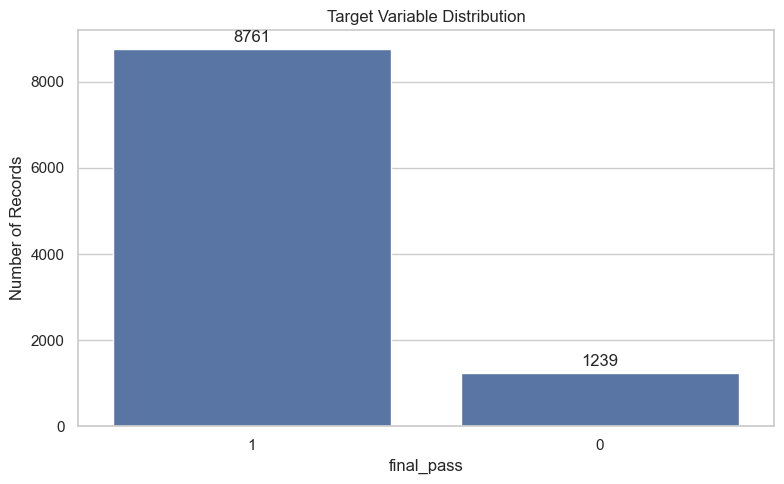

In [31]:
# =============================================================================
# Target Distribution Visualization
# =============================================================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x=TARGET,
    order=df[TARGET].value_counts().index
)

plt.title("Target Variable Distribution")
plt.xlabel(TARGET)
plt.ylabel("Number of Records")

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()

# Save important figure
plt.savefig(
    os.path.join(FIGURE_DIR, "target_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# =============================================================================
# Class Imbalance Assessment
# =============================================================================

max_class_percentage = target_summary["Percentage"].max()
min_class_percentage = target_summary["Percentage"].min()

imbalance_ratio = max_class_percentage / min_class_percentage

print("=" * 70)
print("Class Imbalance Assessment")
print("=" * 70)

print(f"Majority Class Percentage : {max_class_percentage:.2f}%")
print(f"Minority Class Percentage : {min_class_percentage:.2f}%")
print(f"Majority / Minority Ratio : {imbalance_ratio:.2f}")

Class Imbalance Assessment
Majority Class Percentage : 87.61%
Minority Class Percentage : 12.39%
Majority / Minority Ratio : 7.07


In [34]:
# =============================================================================
# Save Target Summary
# =============================================================================

target_summary.to_csv(
    os.path.join(TABLE_DIR, "target_distribution_summary.csv"),
    index=False
)

print("Target distribution summary saved successfully.")

Target distribution summary saved successfully.


## Insights

- The target variable is noticeably imbalanced, with the majority class representing **87.61%** of observations and the minority class representing **12.39%**.
- The majority-to-minority class ratio is approximately **7.07:1**, indicating a significant class imbalance.
- Accuracy alone may therefore provide a misleading evaluation of model performance because a model could achieve high accuracy by primarily predicting the majority class.
- The minority class represents an important quality outcome, so correctly identifying these observations will be important for the FactoryGuard AI system.

### Feature Engineering / Modeling Notes

- We will investigate class-weighted models and, if necessary, resampling techniques during the modeling phase.
- Model evaluation will focus on **precision, recall, F1-score, ROC-AUC, and the confusion matrix**, rather than relying only on accuracy.
- We will avoid applying SMOTE or other resampling techniques during EDA; any such technique will be applied only to the training data during the modeling pipeline to prevent data leakage.

# 3.10 Numerical Feature Analysis

## Objective

In this section, we analyze the numerical features in the Manufacturing Quality Decisions dataset to understand their distributions, ranges, central tendencies, and variability.

## Why are we doing this?

Numerical features such as machine age, temperature, production cost, cycle time, or other manufacturing measurements can have very different ranges and distributions. Understanding these characteristics helps us identify skewness, unusual values, and features that may require special treatment during Feature Engineering.

## What will we get?

We will calculate descriptive statistics and visualize the distributions and spread of the numerical features using histograms and boxplots. These observations will help us understand the behavior of the manufacturing variables before analyzing their relationships with the target.

**Summary:** Numerical feature analysis helps us understand the behavior and quality of continuous and numeric manufacturing variables and identifies potential areas for further investigation.

In [35]:
# =============================================================================
# 3.10 Numerical Feature Analysis
# =============================================================================

# Select numerical features identified in Section 3.6
numerical_df = df[numerical_features]

# Generate descriptive statistics
numerical_summary = numerical_df.describe().T

# Add skewness
numerical_summary["Skewness"] = numerical_df.skew()

# Add number of unique values
numerical_summary["Unique Values"] = numerical_df.nunique()

numerical_summary = numerical_summary.round(2)

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max,Skewness,Unique Values
machine_age_yrs,10000.00,6.04,2.93,0.20,3.97,6.07,8.04,17.98,0.11,1307
temp_c,10000.00,12.63,4.36,5.00,9.30,12.20,15.80,28.10,0.36,211
humidity_pct,10000.00,52.14,12.58,18.20,41.90,52.80,62.30,86.70,-0.09,600
process_speed_units_hr,10000.00,121.87,25.06,60.00,104.90,121.50,139.10,190.00,0.06,1183
defect_severity_0to3,10000.00,0.29,0.73,0.00,0.00,0.00,0.00,3.00,2.49,4
decision_rework,10000.00,0.24,0.43,0.00,0.00,0.00,0.00,1.00,1.20,2
rework_time_min,10000.00,4.85,10.97,0.00,0.00,0.00,0.00,60.00,2.43,513
final_pass,10000.00,0.88,0.33,0.00,1.00,1.00,1.00,1.00,-2.28,2
scrap,10000.00,0.02,0.16,0.00,0.00,0.00,0.00,1.00,6.11,2
total_cycle_time_min,10000.00,34.52,12.10,12.40,27.30,31.30,36.60,97.60,1.88,675


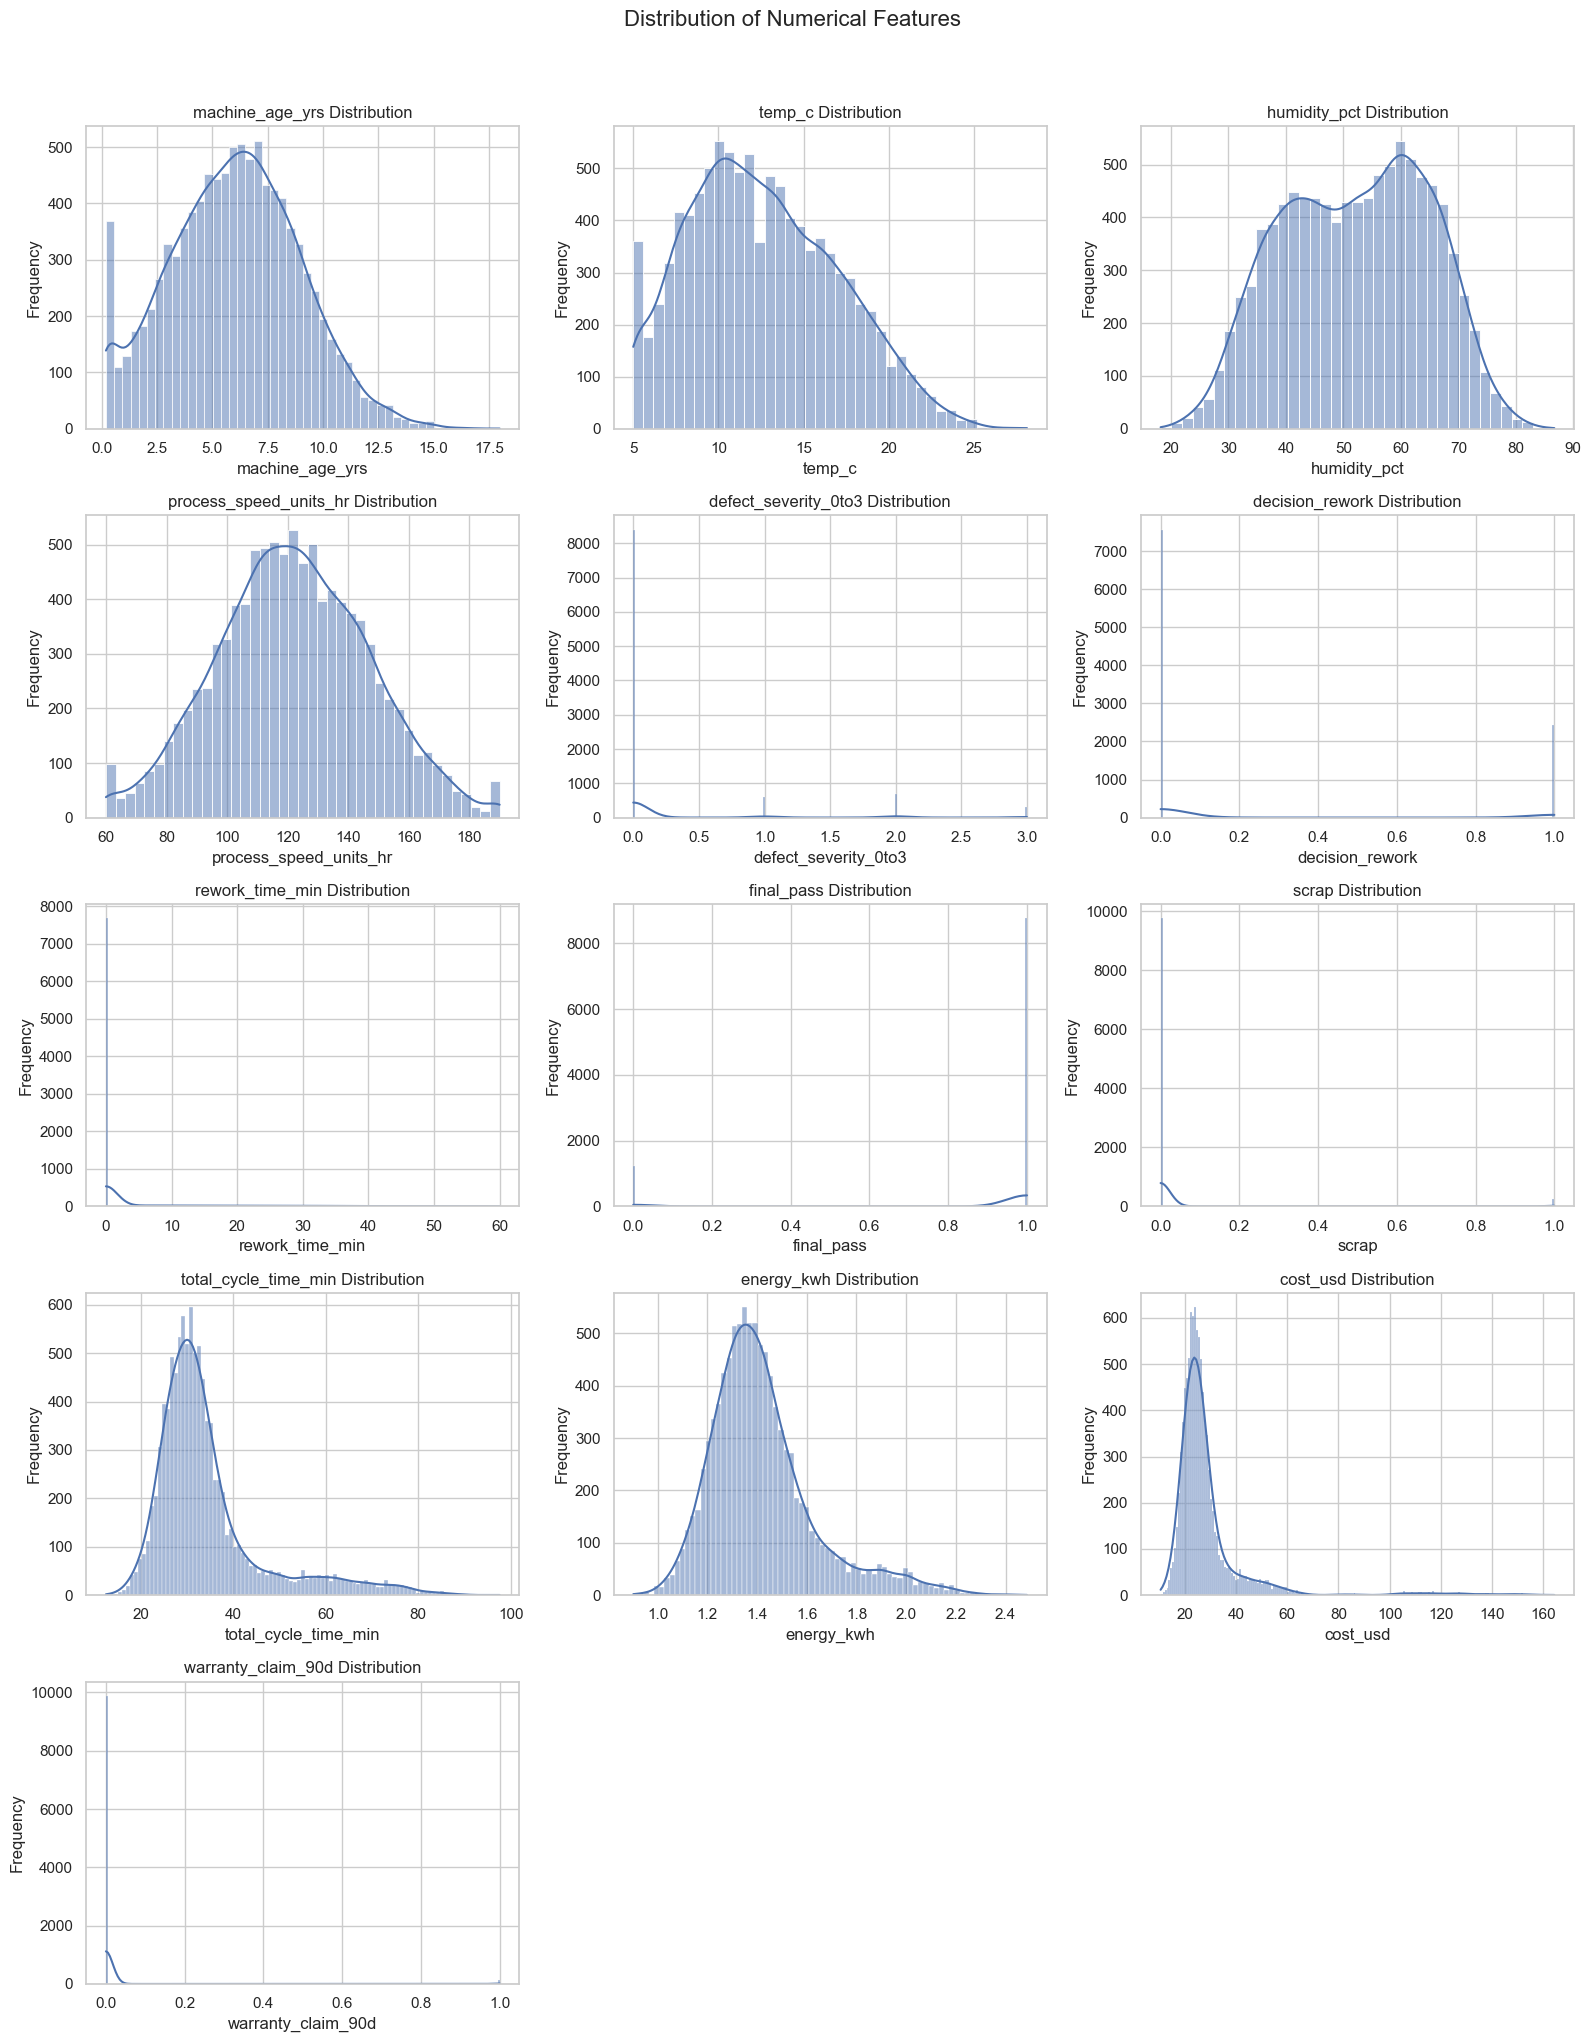

In [36]:
# =============================================================================
# Numerical Feature Distributions
# =============================================================================

n_features = len(numerical_features)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} Distribution")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save important figure
plt.savefig(
    os.path.join(FIGURE_DIR, "numerical_feature_distributions.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

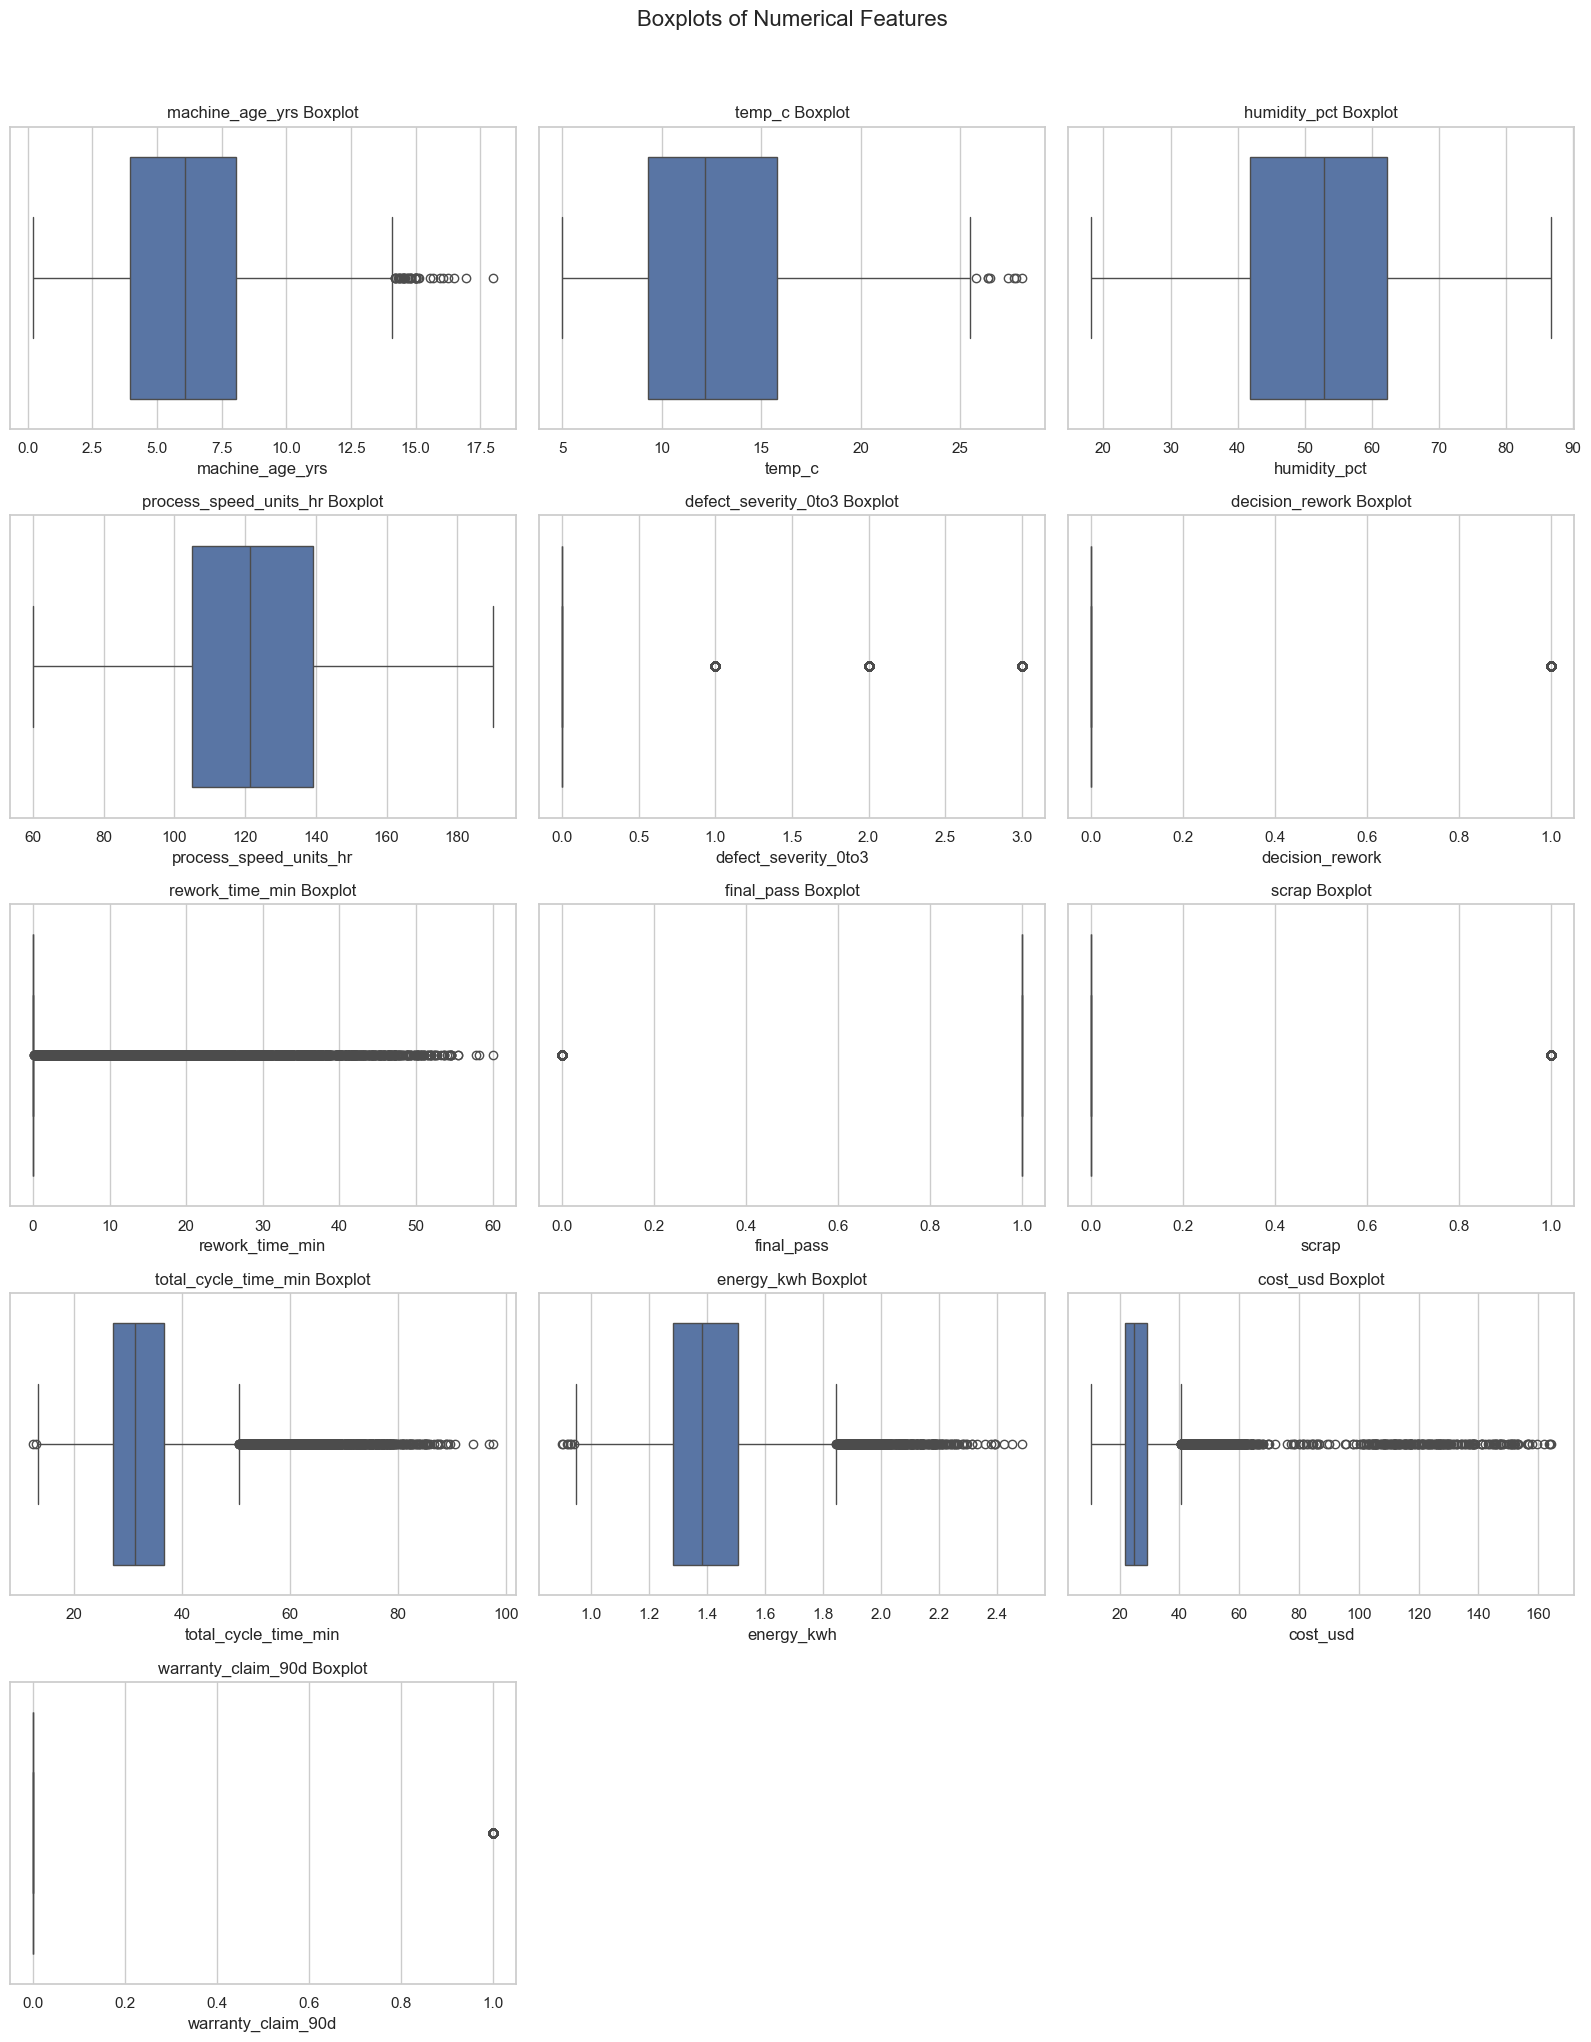

In [37]:
# =============================================================================
# Numerical Feature Boxplots
# =============================================================================

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=df,
        x=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} Boxplot")
    axes[i].set_xlabel(feature)

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Boxplots of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save important figure
plt.savefig(
    os.path.join(FIGURE_DIR, "numerical_feature_boxplots.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

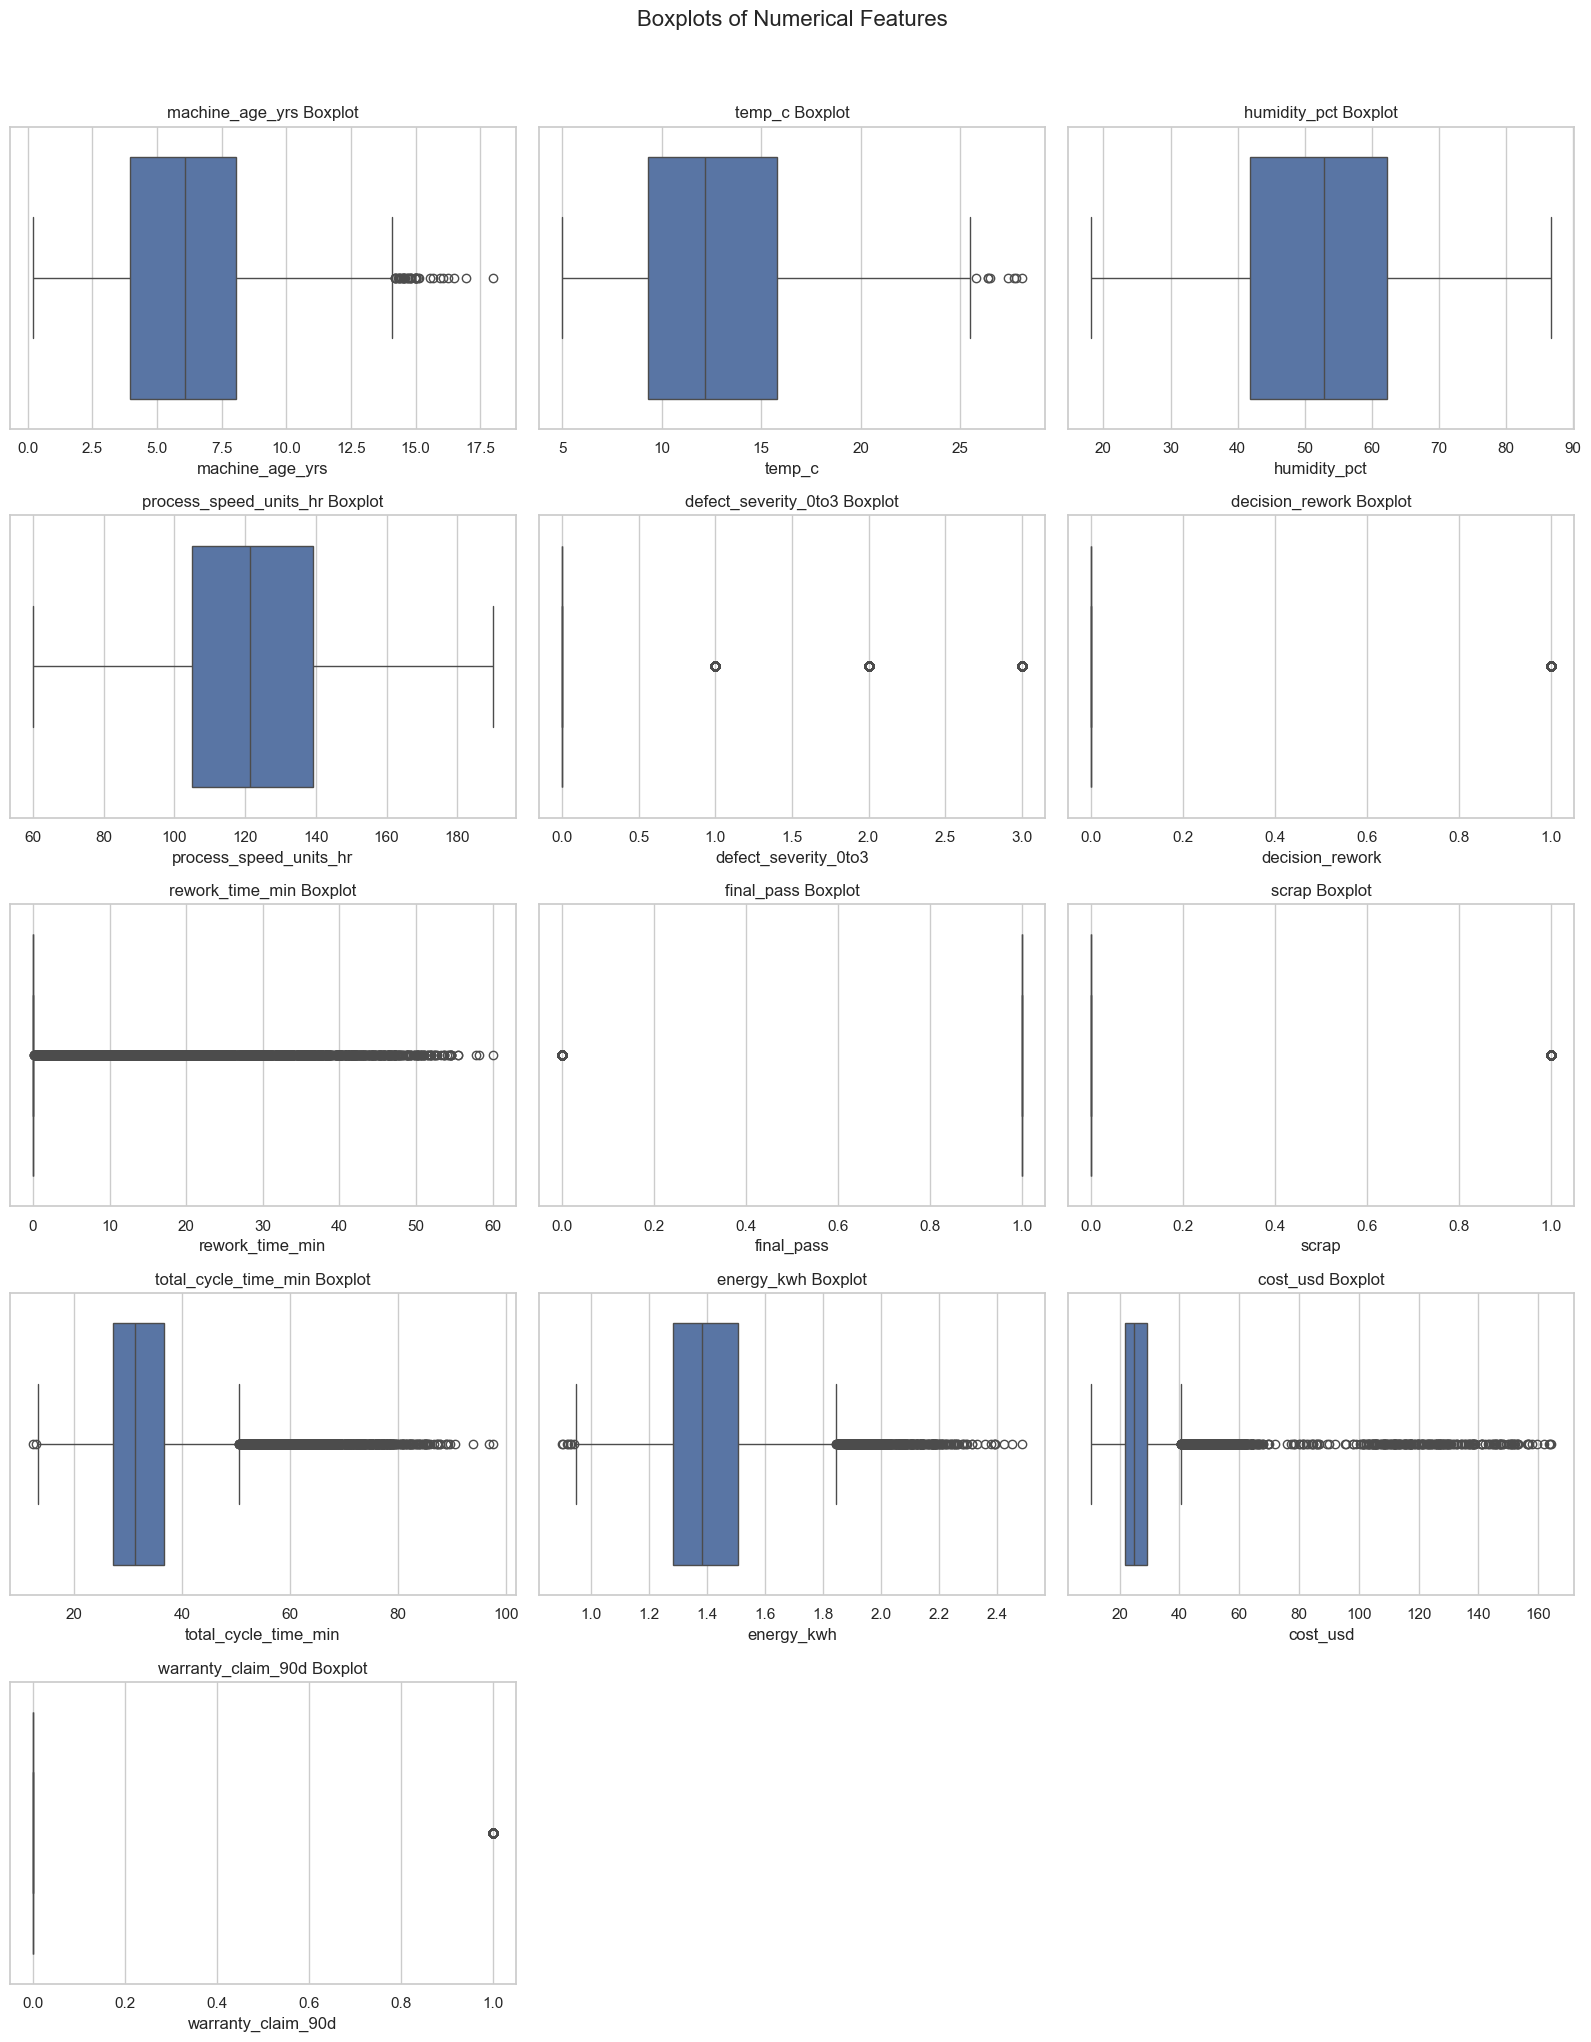

In [38]:
# =============================================================================
# Numerical Feature Boxplots
# =============================================================================

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=df,
        x=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} Boxplot")
    axes[i].set_xlabel(feature)

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Boxplots of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save important figure
plt.savefig(
    os.path.join(FIGURE_DIR, "numerical_feature_boxplots.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# =============================================================================
# Skewness Analysis
# =============================================================================

skewness_summary = (
    numerical_df
    .skew()
    .sort_values(key=abs, ascending=False)
    .to_frame(name="Skewness")
)

skewness_summary["Absolute Skewness"] = (
    skewness_summary["Skewness"].abs()
)

display(skewness_summary.round(2))

,Skewness,Absolute Skewness
warranty_claim_90d,8.78,8.78
scrap,6.11,6.11
cost_usd,4.41,4.41
defect_severity_0to3,2.49,2.49
rework_time_min,2.43,2.43
final_pass,-2.28,2.28
total_cycle_time_min,1.88,1.88
energy_kwh,1.22,1.22
decision_rework,1.20,1.20
temp_c,0.36,0.36


In [41]:
# =============================================================================
# Save Numerical Feature Summary
# =============================================================================

numerical_summary.to_csv(
    os.path.join(TABLE_DIR, "numerical_feature_summary.csv")
)

skewness_summary.to_csv(
    os.path.join(TABLE_DIR, "numerical_feature_skewness.csv")
)

print("Numerical feature summary tables saved successfully.")

Numerical feature summary tables saved successfully.


## Insights

- The numerical features show different ranges and distributions across the manufacturing process.
- Several features appear relatively symmetric, while some may show noticeable skewness.
- The boxplots help identify features containing potentially extreme observations that require further investigation.
- Differences in feature scales are expected and will be considered during Feature Engineering and model preprocessing.
- The numerical distributions provide useful context for the relationship analysis that follows.

### Feature Engineering Notes

- Features with substantial skewness will be considered for appropriate transformation if required.
- Potential outliers will not be removed at this stage. They will be investigated systematically in the dedicated Outlier Analysis section.
- Numerical scaling will be handled during Feature Engineering rather than during EDA.
- No transformation should be applied solely because a feature is not normally distributed; the decision will depend on the model and the business meaning of the feature.

# 3.11 Categorical Feature Analysis

## Objective

In this section, we analyze the categorical features of the Manufacturing Quality Decisions dataset to understand their categories, frequencies, and distribution.

## Why are we doing this?

Categorical features such as plant, production line, shift, material grade, and inspection method can represent important operational differences in manufacturing quality.

Understanding their distributions helps identify dominant categories, rare categories, and features that may provide useful information for predicting the target.

## What will we get?

We will examine the number of unique categories, category frequencies, and the distribution of important categorical features. High-cardinality identifier columns will be handled separately so that the analysis remains meaningful.

**Summary:** Categorical feature analysis helps us understand operational groups and identify categorical variables that may contribute useful information to the quality prediction problem.

In [42]:
# =============================================================================
# 3.11 Categorical Feature Analysis
# =============================================================================

# Create a summary of categorical features
categorical_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Values": [df[col].nunique() for col in categorical_features],
    "Missing Values": [df[col].isna().sum() for col in categorical_features]
})

display(categorical_summary)

,Feature,Unique Values,Missing Values
0,event_id,10000,0
1,event_ts,9996,0
2,plant,3,0
3,line,4,0
4,shift,3,0
5,machine_id,60,0
6,operator_id,450,0
7,material_grade,3,0
8,inspection_method,3,0
9,defect_type,6,0


In [43]:
# =============================================================================
# Category Frequency Tables
# =============================================================================

for feature in categorical_features:

    print("=" * 70)
    print(f"Feature: {feature}")
    print("=" * 70)

    frequency_table = (
        df[feature]
        .value_counts(dropna=False)
        .to_frame(name="Count")
    )

    frequency_table["Percentage"] = (
        frequency_table["Count"] / len(df) * 100
    ).round(2)

    display(frequency_table)

Feature: event_id


,Count,Percentage
event_id,,
M200000,1,0.01
M200001,1,0.01
M200002,1,0.01
M200003,1,0.01
M200004,1,0.01
...,...,...
M209995,1,0.01
M209996,1,0.01
M209997,1,0.01


Feature: event_ts


,Count,Percentage
event_ts,,
2025-12-30 09:22:43,2,0.02
2025-10-05 20:06:49,2,0.02
2025-12-15 22:45:48,2,0.02
2025-12-14 02:39:56,2,0.02
2025-09-01 02:44:28,1,0.01
...,...,...
2025-07-04 06:12:30,1,0.01
2025-07-17 16:44:25,1,0.01
2026-01-13 21:49:49,1,0.01


Feature: plant


...

,Count,Percentage
material_grade,,
grade_A,4981,49.81
grade_B,3459,34.59
grade_C,1560,15.60


Feature: inspection_method


,Count,Percentage
inspection_method,,
vision,3989,39.89
manual,3964,39.64
sensor,2047,20.47


Feature: defect_type


,Count,Percentage
defect_type,,
none,8403,84.03
dimension,332,3.32
finish,324,3.24
contamination,320,3.20
crack,311,3.11
scratch,310,3.10


In [44]:
# =============================================================================
# High-Cardinality Feature Detection
# =============================================================================

HIGH_CARDINALITY_THRESHOLD = 20

high_cardinality_features = [
    feature
    for feature in categorical_features
    if df[feature].nunique() > HIGH_CARDINALITY_THRESHOLD
]

low_cardinality_features = [
    feature
    for feature in categorical_features
    if df[feature].nunique() <= HIGH_CARDINALITY_THRESHOLD
]

print("=" * 70)

print("Low-Cardinality Features:")
print(low_cardinality_features)

print("\nHigh-Cardinality Features:")
print(high_cardinality_features)

print("=" * 70)

Low-Cardinality Features:
['plant', 'line', 'shift', 'material_grade', 'inspection_method', 'defect_type']

High-Cardinality Features:
['event_id', 'event_ts', 'machine_id', 'operator_id']


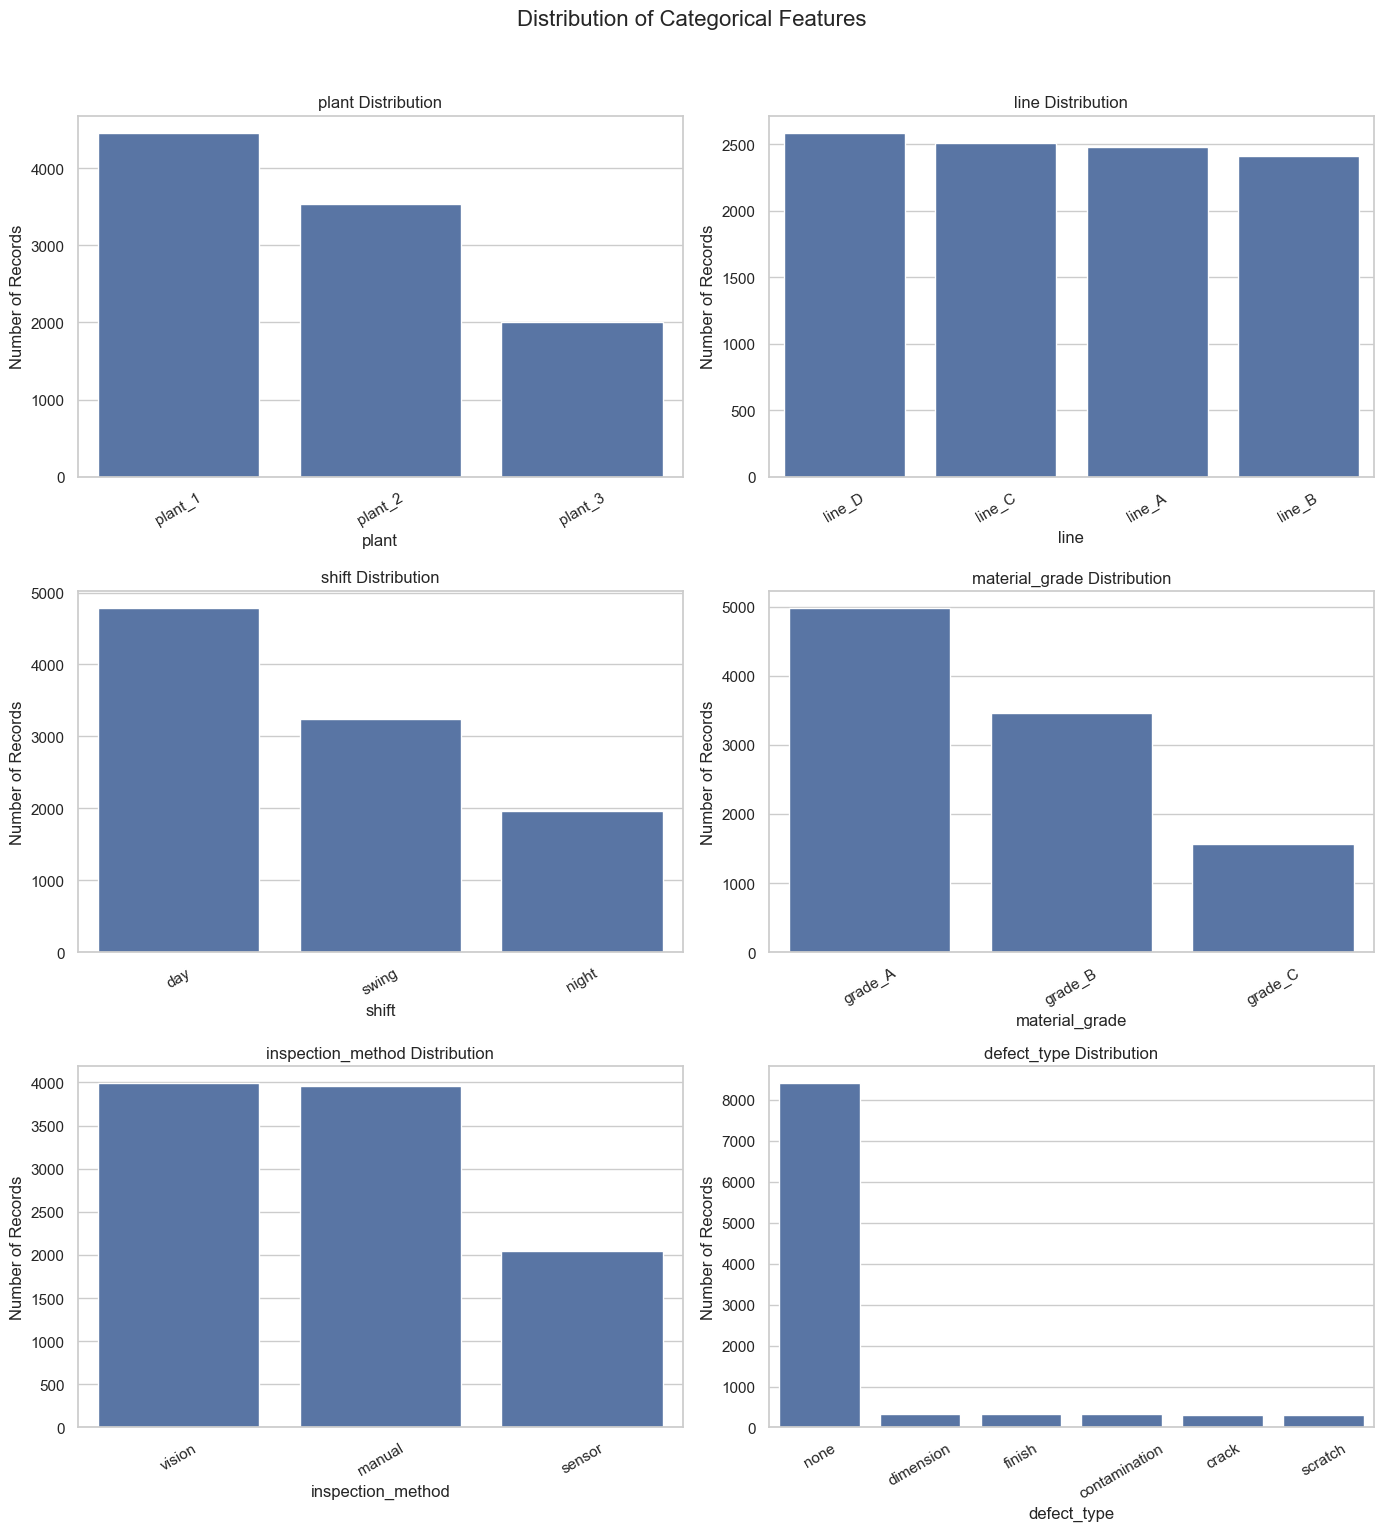

In [45]:
# =============================================================================
# Low-Cardinality Categorical Feature Distributions
# =============================================================================

n_features = len(low_cardinality_features)

n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(low_cardinality_features):

    order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} Distribution")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Number of Records")

    # Rotate labels when necessary
    axes[i].tick_params(axis="x", rotation=30)

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Distribution of Categorical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save important figure
plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "categorical_feature_distributions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# =============================================================================
# Top Categories of High-Cardinality Features
# =============================================================================

for feature in high_cardinality_features:

    print("=" * 70)
    print(f"Top Categories: {feature}")
    print("=" * 70)

    top_categories = (
        df[feature]
        .value_counts()
        .head(10)
        .to_frame(name="Count")
    )

    top_categories["Percentage"] = (
        top_categories["Count"] / len(df) * 100
    ).round(2)

    display(top_categories)

Top Categories: event_id


,Count,Percentage
event_id,,
M200000,1,0.01
M200001,1,0.01
M200002,1,0.01
M200003,1,0.01
M200004,1,0.01
M200005,1,0.01
M200006,1,0.01
M200007,1,0.01
M200008,1,0.01


Top Categories: event_ts


,Count,Percentage
event_ts,,
2025-12-30 09:22:43,2,0.02
2025-10-05 20:06:49,2,0.02
2025-12-15 22:45:48,2,0.02
2025-12-14 02:39:56,2,0.02
2025-09-01 02:44:28,1,0.01
2025-10-21 21:02:50,1,0.01
2025-09-12 18:28:42,1,0.01
2025-10-01 07:10:50,1,0.01
2025-09-05 22:16:08,1,0.01


Top Categories: machine_id


,Count,Percentage
machine_id,,
MC118,196,1.96
MC107,188,1.88
MC126,188,1.88
MC140,185,1.85
MC130,183,1.83
MC154,182,1.82
MC150,182,1.82
MC139,181,1.81
MC151,181,1.81


Top Categories: operator_id


,Count,Percentage
operator_id,,
OP1434,36,0.36
OP1430,35,0.35
OP1234,35,0.35
OP1327,33,0.33
OP1111,33,0.33
OP1073,33,0.33
OP1106,33,0.33
OP1411,33,0.33
OP1082,33,0.33


In [47]:
# =============================================================================
# Save Categorical Feature Summary
# =============================================================================

categorical_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "categorical_feature_summary.csv"
    ),
    index=False
)

print("Categorical feature summary saved successfully.")

Categorical feature summary saved successfully.


## Insights

- The categorical features represent different manufacturing characteristics such as plants, production lines, shifts, materials, and operational identifiers.
- Most low-cardinality categorical features can be analyzed directly using their category frequencies.
- High-cardinality features require more careful treatment because directly encoding a large number of categories can increase model complexity.
- The frequency distributions also help identify dominant and relatively rare categories that may require consideration during Feature Engineering.

### Feature Engineering Notes

- Low-cardinality categorical variables can generally be handled using One-Hot Encoding during Feature Engineering.
- High-cardinality identifiers such as `machine_id` and `operator_id` should not automatically be one-hot encoded.
- Identifier-like features will be evaluated based on their business meaning and predictive value before deciding whether to include them in the final model.
- Rare categories may be grouped if necessary during Feature Engineering.
- No encoding is performed during EDA.


# 3.12 Univariate Analysis

## Objective

In this section, we perform a focused univariate analysis of selected manufacturing features by examining one variable at a time.

## Why are we doing this?

Although the previous sections provided an overall analysis of numerical and categorical features, individual features may contain patterns that deserve closer attention. Univariate analysis allows us to examine the distribution, concentration, and variability of important manufacturing variables independently.

This helps us identify dominant categories, unusual distributions, and potentially important operational characteristics before studying relationships between multiple variables.

## What will we get?

We will examine selected numerical and categorical features individually using appropriate visualizations and summary statistics. The analysis will focus on features that have clear manufacturing or business relevance rather than repeating every distribution from the previous sections.

**Summary:** Focused univariate analysis provides a closer look at important individual manufacturing variables and prepares us for relationship-based analysis in the following sections.

In [48]:
# =============================================================================
# 3.12 Univariate Analysis
# =============================================================================

# Key numerical manufacturing features
key_numerical_features = [
    "machine_age_yrs",
    "temp_c",
    "humidity_pct",
    "process_speed_units_hr",
    "defect_severity_0to3",
    "rework_time_min",
    "total_cycle_time_min",
    "energy_kwh",
    "cost_usd"
]

# Keep only columns that actually exist in the dataset
key_numerical_features = [
    feature for feature in key_numerical_features
    if feature in df.columns
]

print("Key Numerical Features:")
print(key_numerical_features)

Key Numerical Features:
['machine_age_yrs', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'defect_severity_0to3', 'rework_time_min', 'total_cycle_time_min', 'energy_kwh', 'cost_usd']


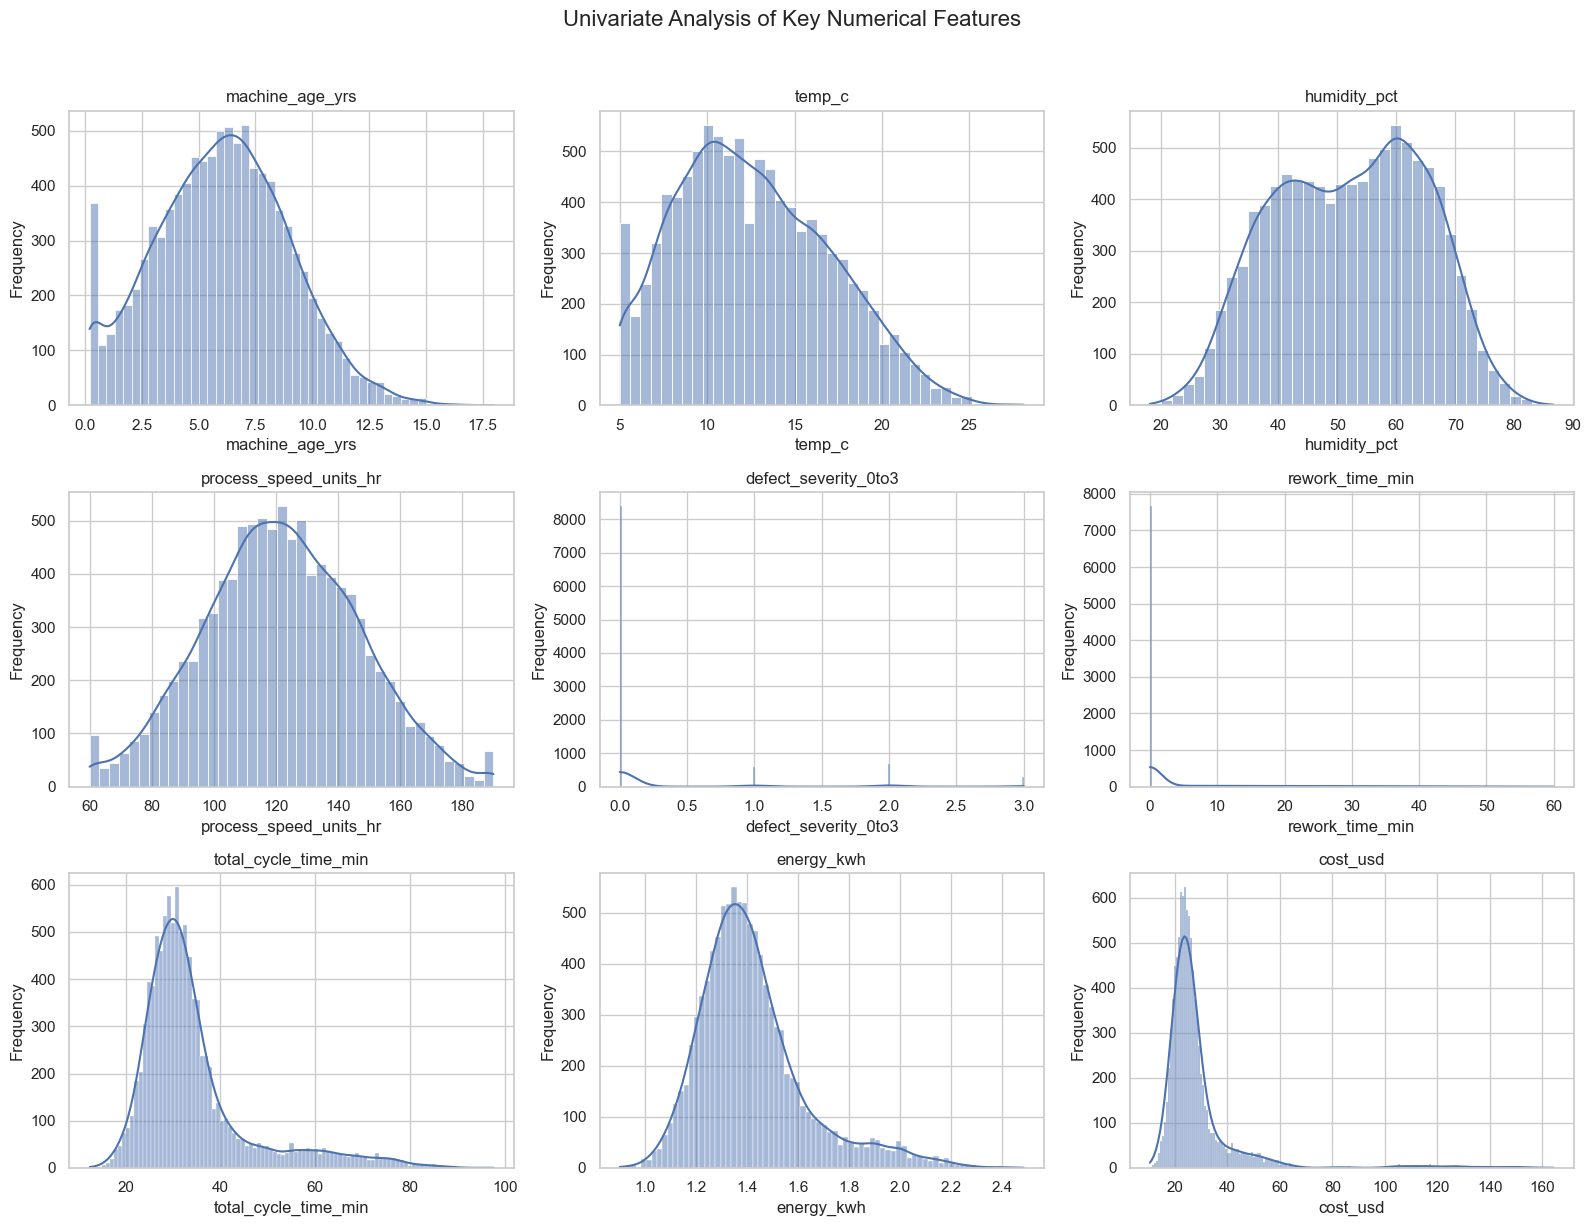

In [49]:
# =============================================================================
# Univariate Analysis - Numerical Features
# =============================================================================

n_features = len(key_numerical_features)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(key_numerical_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Univariate Analysis of Key Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "univariate_numerical_analysis.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
# =============================================================================
# Key Categorical Features
# =============================================================================

key_categorical_features = [
    "plant",
    "line",
    "shift",
    "material_grade",
    "inspection_method"
]

key_categorical_features = [
    feature for feature in key_categorical_features
    if feature in df.columns
]

print("Key Categorical Features:")
print(key_categorical_features)

Key Categorical Features:
['plant', 'line', 'shift', 'material_grade', 'inspection_method']


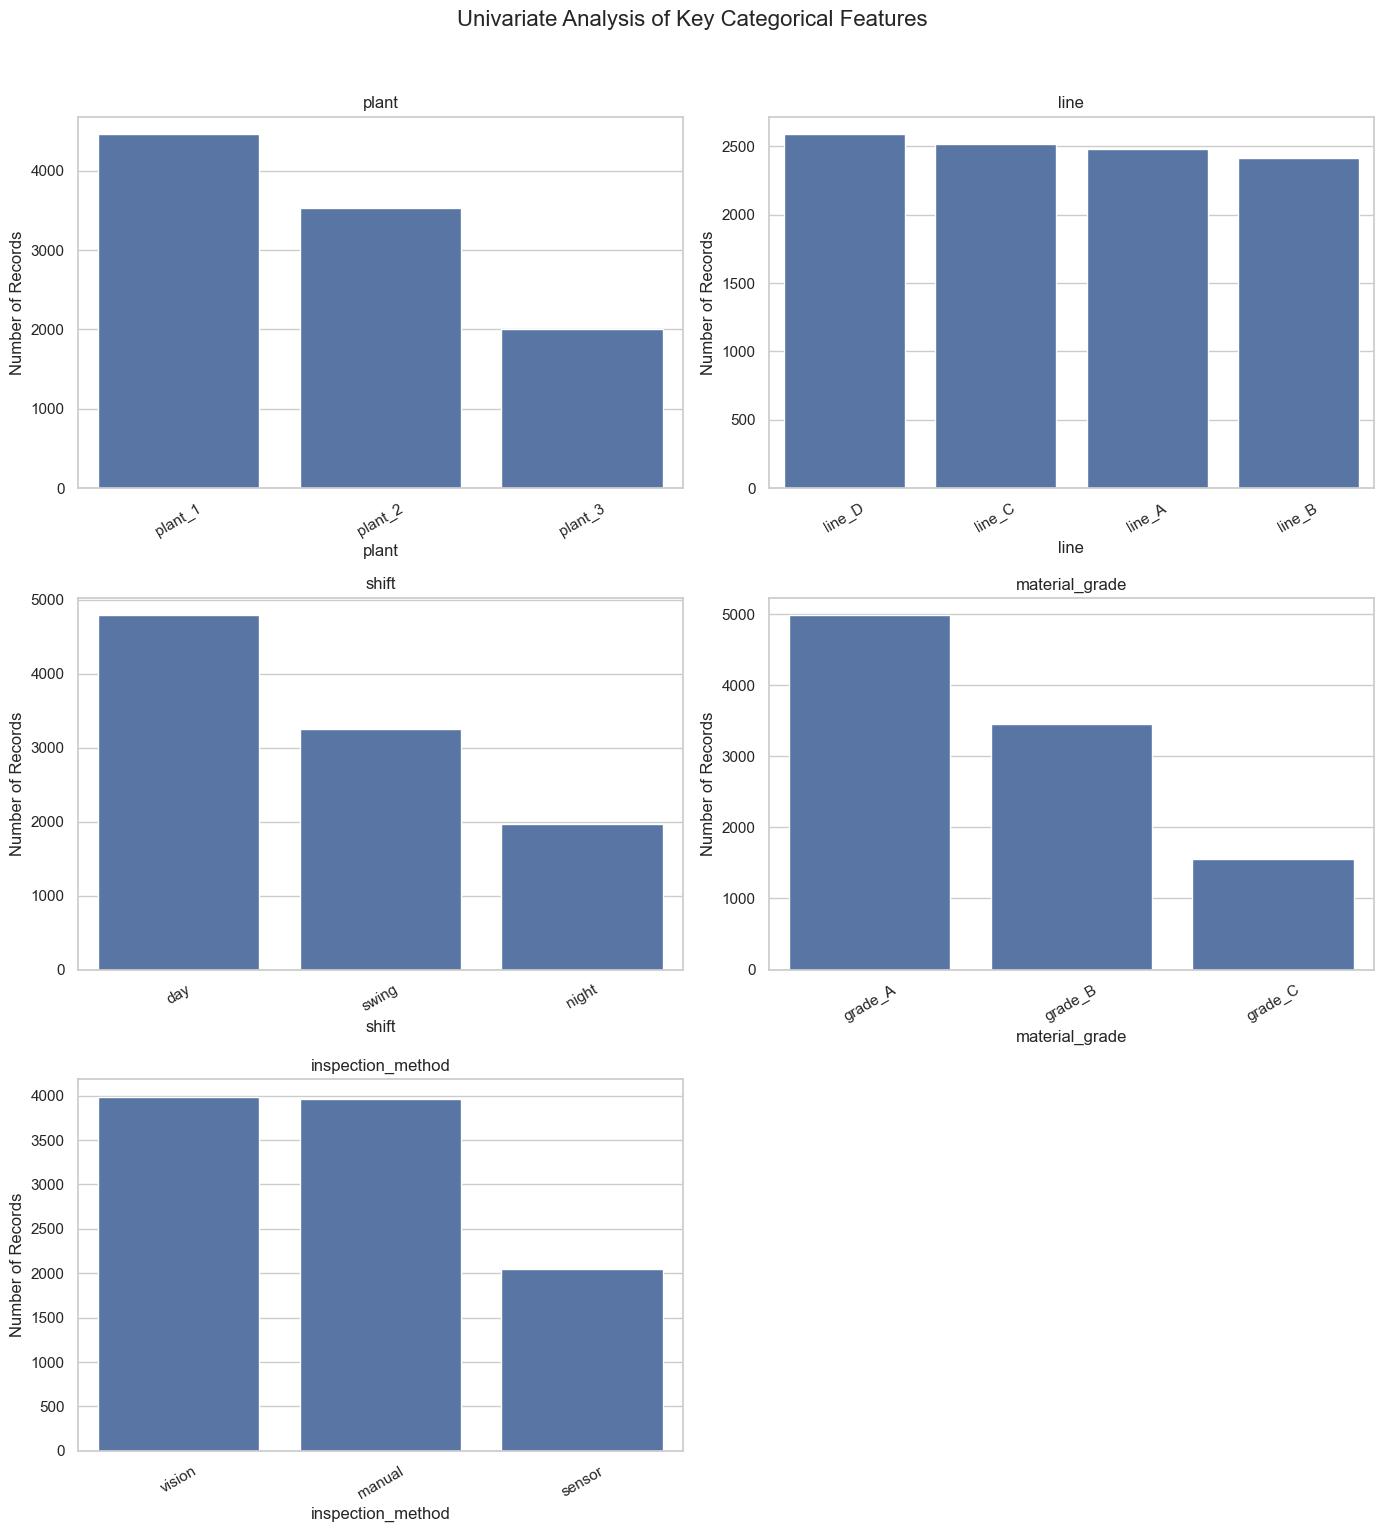

In [51]:
# =============================================================================
# Univariate Analysis - Categorical Features
# =============================================================================

n_features = len(key_categorical_features)

n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(key_categorical_features):

    order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Number of Records")
    axes[i].tick_params(axis="x", rotation=30)

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Univariate Analysis of Key Categorical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "univariate_categorical_analysis.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
# =============================================================================
# Key Numerical Feature Statistics
# =============================================================================

key_numerical_summary = (
    df[key_numerical_features]
    .describe()
    .T
)

key_numerical_summary["Skewness"] = (
    df[key_numerical_features].skew()
)

key_numerical_summary = key_numerical_summary.round(2)

display(key_numerical_summary)

,count,mean,std,min,25%,50%,75%,max,Skewness
machine_age_yrs,10000.00,6.04,2.93,0.20,3.97,6.07,8.04,17.98,0.11
temp_c,10000.00,12.63,4.36,5.00,9.30,12.20,15.80,28.10,0.36
humidity_pct,10000.00,52.14,12.58,18.20,41.90,52.80,62.30,86.70,-0.09
process_speed_units_hr,10000.00,121.87,25.06,60.00,104.90,121.50,139.10,190.00,0.06
defect_severity_0to3,10000.00,0.29,0.73,0.00,0.00,0.00,0.00,3.00,2.49
rework_time_min,10000.00,4.85,10.97,0.00,0.00,0.00,0.00,60.00,2.43
total_cycle_time_min,10000.00,34.52,12.10,12.40,27.30,31.30,36.60,97.60,1.88
energy_kwh,10000.00,1.42,0.21,0.90,1.28,1.38,1.51,2.49,1.22
cost_usd,10000.00,29.04,17.23,10.51,21.63,24.85,29.15,164.31,4.41


In [53]:
# =============================================================================
# Save Univariate Summary
# =============================================================================

key_numerical_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "univariate_numerical_summary.csv"
    )
)

print("Univariate numerical summary saved successfully.")

Univariate numerical summary saved successfully.


## Insights

- The selected numerical features show different distributions and levels of variability across the manufacturing process.
- Operational variables such as machine age, temperature, humidity, and process speed show distinct ranges that may influence production quality.
- The categorical variables reveal how the manufacturing records are distributed across plants, production lines, shifts, material grades, and inspection methods.
- Some features may show skewed or concentrated distributions, which will be investigated further before making preprocessing decisions.

### Feature Engineering Notes

- Numerical features with substantial skewness may require transformation depending on the selected modeling algorithms.
- Categorical features such as plant, line, shift, material grade, and inspection method will require suitable encoding during Feature Engineering.
- No transformation or encoding is performed during this section.
- The next step will investigate relationships between individual features and the target variable.

# 3.13 Bivariate Analysis

## Objective

In this section, we analyze the relationship between individual manufacturing features and the target variable `final_pass`.

## Why are we doing this?

Bivariate analysis helps us understand whether differences in manufacturing conditions, equipment, materials, and operating conditions are associated with the final quality outcome.

This is important because the relationships discovered here can help us identify potentially useful predictive features and guide Feature Engineering and model development.

## What will we get?

We will compare important numerical and categorical manufacturing features across the target classes. This will help us identify differences in operating conditions between passed and failed production records.

Only features that could reasonably be available before the final quality decision will be emphasized for predictive analysis. This helps reduce the risk of target leakage.

**Summary:** Bivariate analysis identifies potentially meaningful relationships between manufacturing conditions and the final quality outcome and provides direction for Feature Engineering.

In [54]:
# =============================================================================
# 3.13 Bivariate Analysis
# =============================================================================

TARGET = "final_pass"

# Numerical features that could reasonably be available before the final decision
bivariate_numerical_features = [
    "machine_age_yrs",
    "temp_c",
    "humidity_pct",
    "process_speed_units_hr",
    "energy_kwh",
    "cost_usd",
    "total_cycle_time_min"
]

# Categorical operational features
bivariate_categorical_features = [
    "plant",
    "line",
    "shift",
    "material_grade",
    "inspection_method"
]

# Keep only columns that exist
bivariate_numerical_features = [
    feature for feature in bivariate_numerical_features
    if feature in df.columns
]

bivariate_categorical_features = [
    feature for feature in bivariate_categorical_features
    if feature in df.columns
]

print("Numerical Features:")
print(bivariate_numerical_features)

print("\nCategorical Features:")
print(bivariate_categorical_features)

Numerical Features:
['machine_age_yrs', 'temp_c', 'humidity_pct', 'process_speed_units_hr', 'energy_kwh', 'cost_usd', 'total_cycle_time_min']

Categorical Features:
['plant', 'line', 'shift', 'material_grade', 'inspection_method']


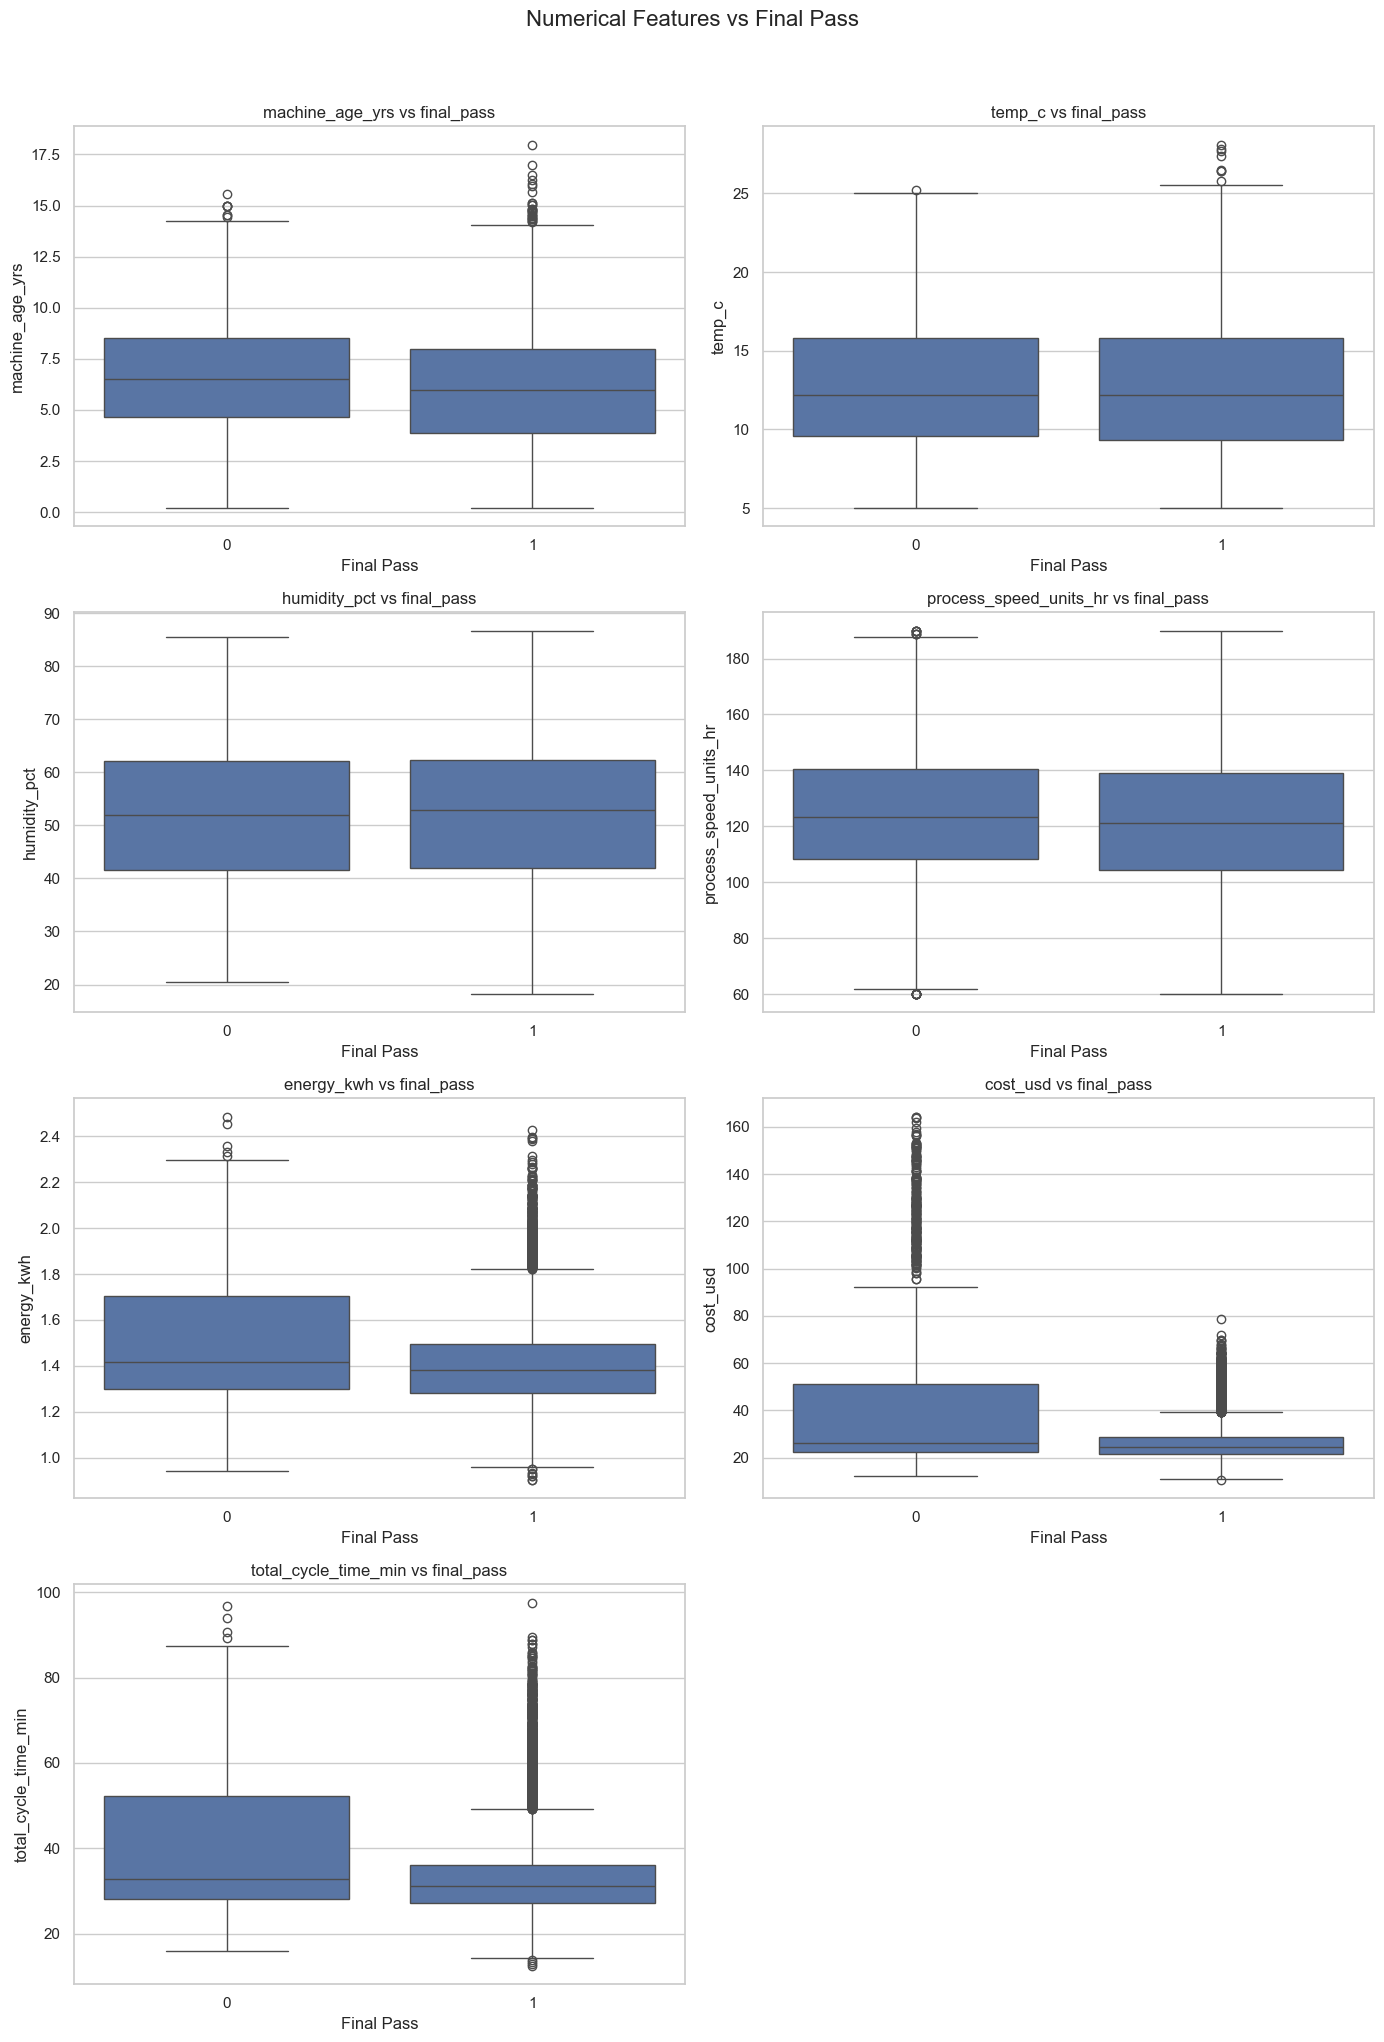

In [55]:
# =============================================================================
# Numerical Features vs Target
# =============================================================================

n_features = len(bivariate_numerical_features)

n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(bivariate_numerical_features):

    sns.boxplot(
        data=df,
        x=TARGET,
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} vs {TARGET}")
    axes[i].set_xlabel("Final Pass")
    axes[i].set_ylabel(feature)

for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Numerical Features vs Final Pass",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "numerical_features_vs_target.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# =============================================================================
# Numerical Features - Target Group Statistics
# =============================================================================

for feature in bivariate_numerical_features:

    print("=" * 70)
    print(f"{feature} by {TARGET}")
    print("=" * 70)

    summary = (
        df.groupby(TARGET)[feature]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(2)
    )

    display(summary)

machine_age_yrs by final_pass


,count,mean,median,std,min,max
final_pass,,,,,,
0,1239,6.60,6.51,2.92,0.20,15.57
1,8761,5.96,5.99,2.92,0.20,17.98


temp_c by final_pass


,count,mean,median,std,min,max
final_pass,,,,,,
0,1239,12.72,12.20,4.25,5.00,25.20
1,8761,12.62,12.20,4.37,5.00,28.10


humidity_pct by final_pass


...

,count,mean,median,std,min,max
final_pass,,,,,,
0,1239,1.51,1.42,0.29,0.94,2.49
1,8761,1.41,1.38,0.20,0.90,2.43


cost_usd by final_pass


,count,mean,median,std,min,max
final_pass,,,,,,
0,1239,46.43,26.35,39.48,12.13,164.31
1,8761,26.59,24.71,8.35,10.51,78.63


total_cycle_time_min by final_pass


,count,mean,median,std,min,max
final_pass,,,,,,
0,1239,40.13,32.70,17.39,15.90,96.90
1,8761,33.73,31.10,10.92,12.40,97.60


In [57]:
# =============================================================================
# Categorical Features vs Target
# =============================================================================

for feature in bivariate_categorical_features:

    print("=" * 70)
    print(f"{feature} vs {TARGET}")
    print("=" * 70)

    category_target_rate = pd.crosstab(
        df[feature],
        df[TARGET],
        normalize="index"
    ).mul(100).round(2)

    display(category_target_rate)

plant vs final_pass


final_pass,0,1
plant,,
plant_1,12.49,87.51
plant_2,12.01,87.99
plant_3,12.82,87.18


line vs final_pass


final_pass,0,1
line,,
line_A,12.33,87.67
line_B,11.59,88.41
line_C,13.01,86.99
line_D,12.60,87.40


shift vs final_pass


final_pass,0,1
shift,,
day,12.08,87.92
night,13.27,86.73
swing,12.32,87.68


material_grade vs final_pass


final_pass,0,1
material_grade,,
grade_A,11.91,88.09
grade_B,12.58,87.42
grade_C,13.53,86.47


inspection_method vs final_pass


final_pass,0,1
inspection_method,,
manual,12.76,87.24
sensor,11.09,88.91
vision,12.68,87.32


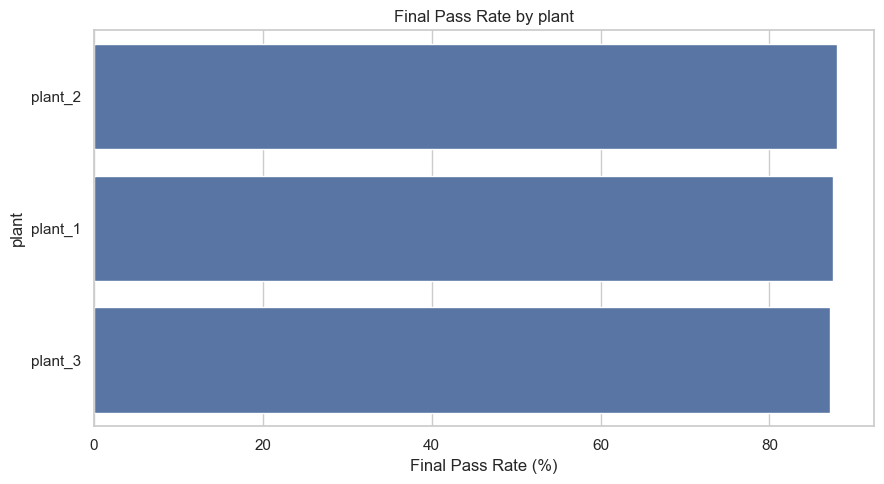

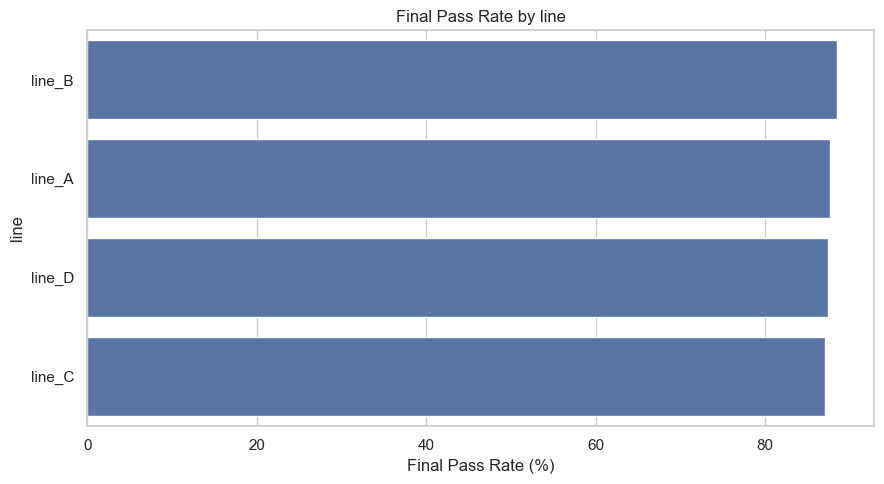

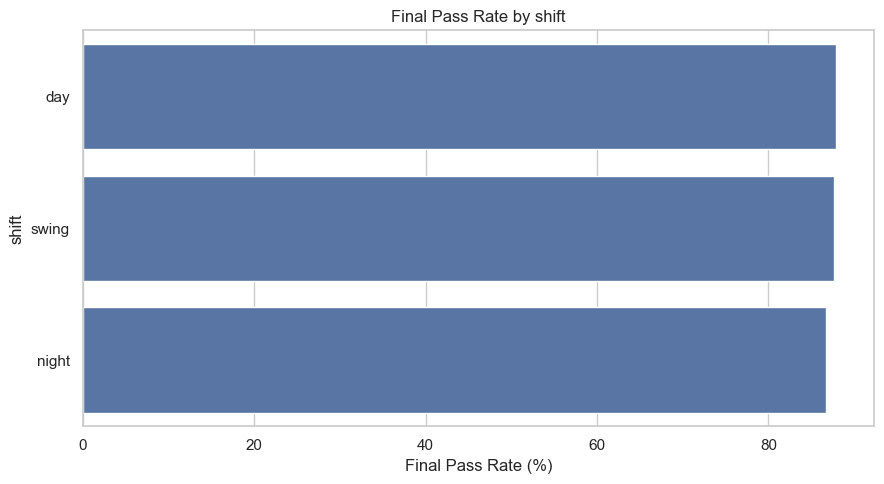

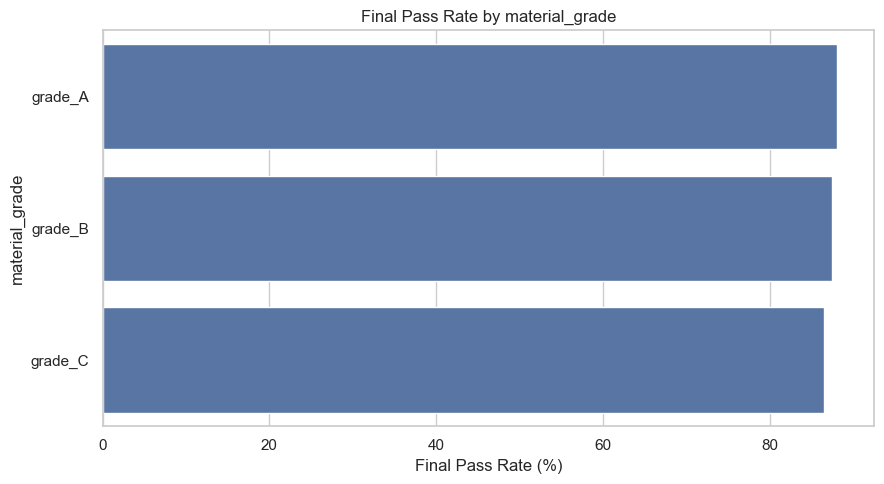

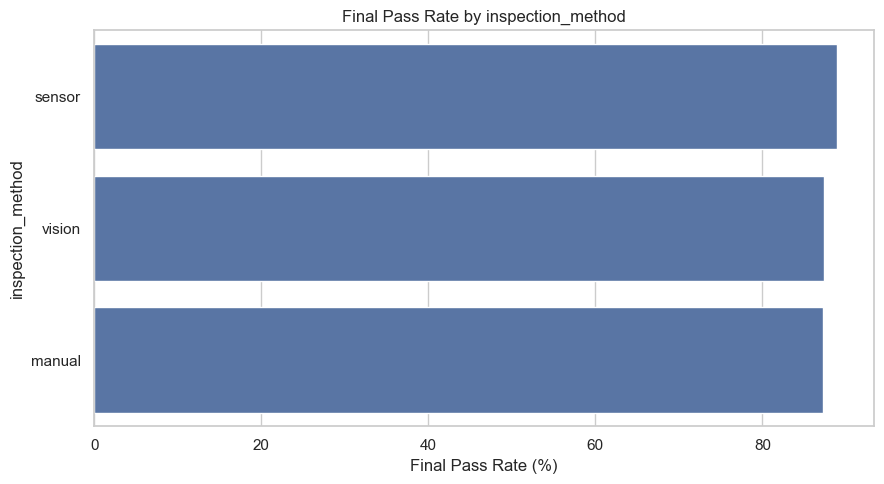

In [58]:
# =============================================================================
# Categorical Features - Target Rate
# =============================================================================

for feature in bivariate_categorical_features:

    target_rate = (
        df.groupby(feature)[TARGET]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    sns.barplot(
        x=target_rate.values,
        y=target_rate.index
    )

    plt.title(f"Final Pass Rate by {feature}")
    plt.xlabel("Final Pass Rate (%)")
    plt.ylabel(feature)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURE_DIR,
            f"final_pass_rate_by_{feature}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [59]:
# =============================================================================
# Best and Worst Performing Categories
# =============================================================================

category_insights = []

for feature in bivariate_categorical_features:

    target_rate = (
        df.groupby(feature)[TARGET]
        .mean()
        .mul(100)
        .sort_values()
    )

    category_insights.append({
        "Feature": feature,
        "Lowest Pass Rate Category": target_rate.index[0],
        "Lowest Pass Rate (%)": round(target_rate.iloc[0], 2),
        "Highest Pass Rate Category": target_rate.index[-1],
        "Highest Pass Rate (%)": round(target_rate.iloc[-1], 2)
    })

category_insights_df = pd.DataFrame(category_insights)

display(category_insights_df)

,Feature,Lowest Pass Rate Category,Lowest Pass Rate (%),Highest Pass Rate Category,Highest Pass Rate (%)
0,plant,plant_3,87.18,plant_2,87.99
1,line,line_C,86.99,line_B,88.41
2,shift,night,86.73,day,87.92
3,material_grade,grade_C,86.47,grade_A,88.09
4,inspection_method,manual,87.24,sensor,88.91


In [60]:
# =============================================================================
# Save Bivariate Analysis Tables
# =============================================================================

category_insights_df.to_csv(
    os.path.join(
        TABLE_DIR,
        "categorical_target_rate_summary.csv"
    ),
    index=False
)

print("Bivariate analysis summary saved successfully.")

Bivariate analysis summary saved successfully.


## Insights

- Several manufacturing variables show differences between the `final_pass` classes.
- Numerical feature comparisons indicate whether operating conditions such as temperature, humidity, process speed, machine age, and cycle time differ between passed and failed production records.
- Categorical analysis reveals differences in final-pass rates across manufacturing plants, production lines, shifts, material grades, and inspection methods.
- The strongest differences identified in this section may represent potentially useful predictive features for the machine learning model.

### Business Insights

- The analysis helps identify manufacturing groups or operating conditions associated with lower quality outcomes.
- Production lines or plants with relatively lower pass rates may require additional investigation.
- Differences across shifts or material grades may indicate operational factors that influence manufacturing quality.

### Feature Engineering Notes

- Features showing meaningful relationships with `final_pass` will be considered during Feature Engineering.
- Categorical variables will require appropriate encoding.
- Numerical variables may require scaling depending on the final model selection.
- A relationship with the target does not automatically imply causation.
- Potentially post-outcome variables such as `decision_rework`, `rework_time_min`, `scrap`, and `warranty_claim_90d` are excluded from this predictive analysis to reduce the risk of target leakage.

# 3.14 Multivariate Analysis

## Objective

In this section, we analyze multiple manufacturing features together to identify combined patterns and interactions that may not be visible when examining individual variables separately.

## Why are we doing this?

Manufacturing quality can depend on a combination of operational conditions rather than a single feature. Multivariate analysis helps us investigate these combined patterns and identify groups or combinations of features associated with different quality outcomes.

## What will we get?

We will examine selected combinations of categorical and numerical features and compare their relationship with the target variable. This can reveal operational patterns that may be useful for Feature Engineering and predictive modeling.

**Summary:** Multivariate analysis helps us understand how multiple manufacturing factors interact and whether particular combinations are associated with different quality outcomes.

In [61]:
# =============================================================================
# 3.14 Multivariate Analysis
# Plant + Shift + Final Pass
# =============================================================================

plant_shift_pass = pd.crosstab(
    [df["plant"], df["shift"]],
    df[TARGET],
    normalize="index"
).mul(100).round(2)

display(plant_shift_pass)

final_pass        0     1
plant   shift            
plant_1 day   11.83 88.17
        night 13.34 86.66
        swing 12.94 87.06
plant_2 day   11.71 88.29
        night 12.55 87.45
        swing 12.14 87.86
plant_3 day   13.27 86.73
        night 14.36 85.64
        swing 11.21 88.79

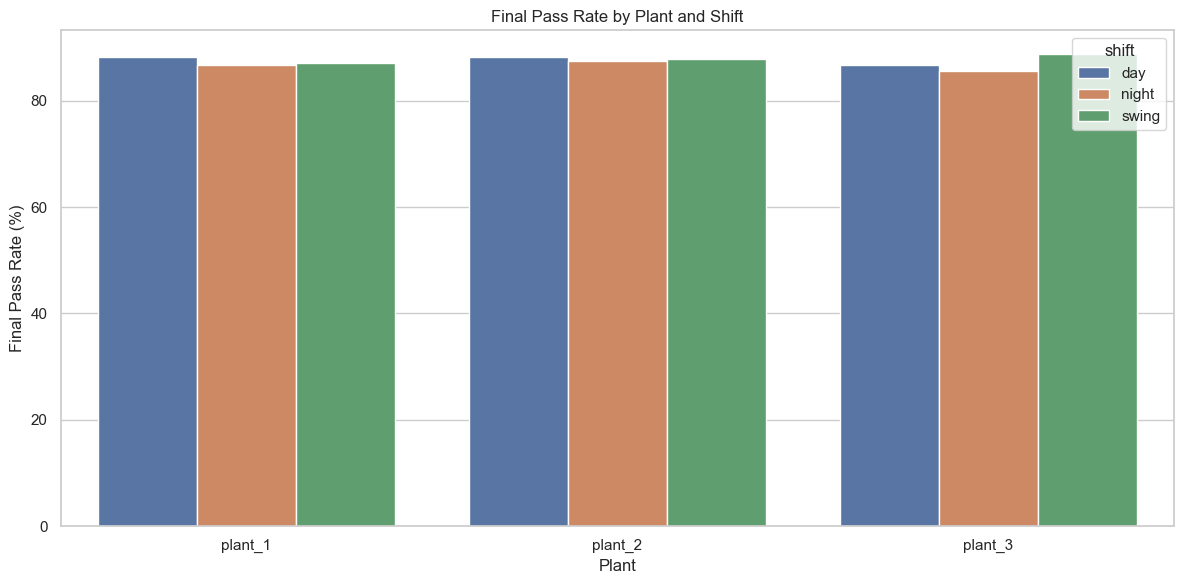

In [62]:
# =============================================================================
# Plant and Shift vs Final Pass
# =============================================================================

plant_shift_pass_plot = (
    df.groupby(["plant", "shift"])[TARGET]
    .mean()
    .mul(100)
    .reset_index(name="Final Pass Rate")
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plant_shift_pass_plot,
    x="plant",
    y="Final Pass Rate",
    hue="shift"
)

plt.title("Final Pass Rate by Plant and Shift")
plt.xlabel("Plant")
plt.ylabel("Final Pass Rate (%)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "final_pass_rate_plant_shift.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# =============================================================================
# Material Grade + Shift + Final Pass
# =============================================================================

material_shift_pass = (
    df.groupby(["material_grade", "shift"])[TARGET]
    .mean()
    .mul(100)
    .reset_index(name="Final Pass Rate")
)

display(
    material_shift_pass.sort_values(
        "Final Pass Rate",
        ascending=False
    )
)

,material_grade,shift,Final Pass Rate
0,grade_A,day,88.56
8,grade_C,swing,87.81
3,grade_B,day,87.73
1,grade_A,night,87.67
5,grade_B,swing,87.66
2,grade_A,swing,87.66
6,grade_C,day,86.33
4,grade_B,night,86.31
7,grade_C,night,84.74


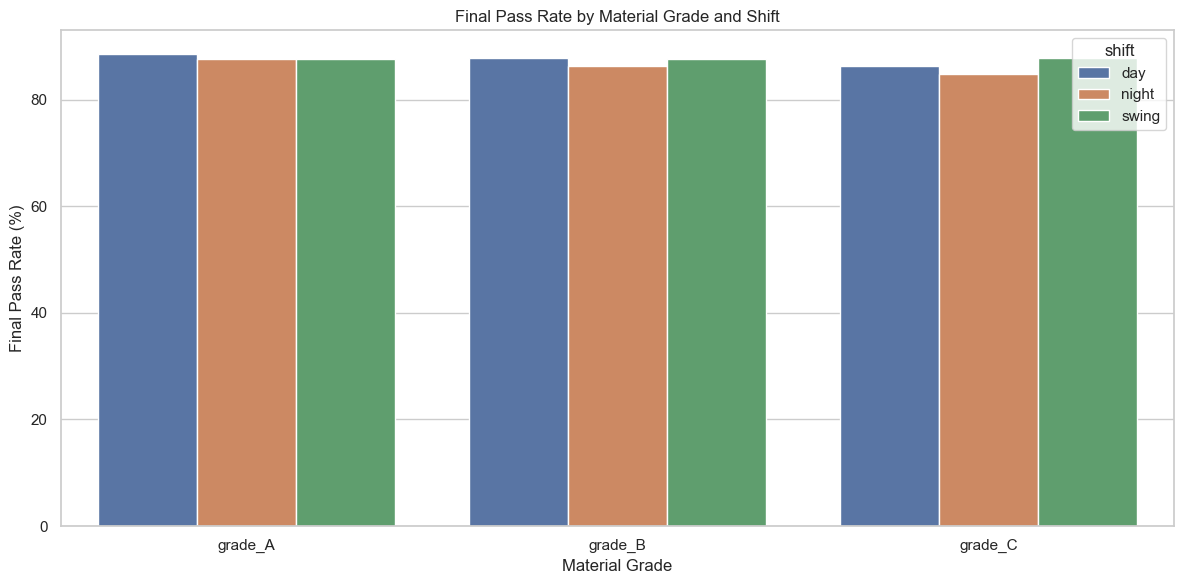

In [64]:
# =============================================================================
# Material Grade and Shift vs Final Pass
# =============================================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=material_shift_pass,
    x="material_grade",
    y="Final Pass Rate",
    hue="shift"
)

plt.title("Final Pass Rate by Material Grade and Shift")
plt.xlabel("Material Grade")
plt.ylabel("Final Pass Rate (%)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "final_pass_rate_material_shift.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

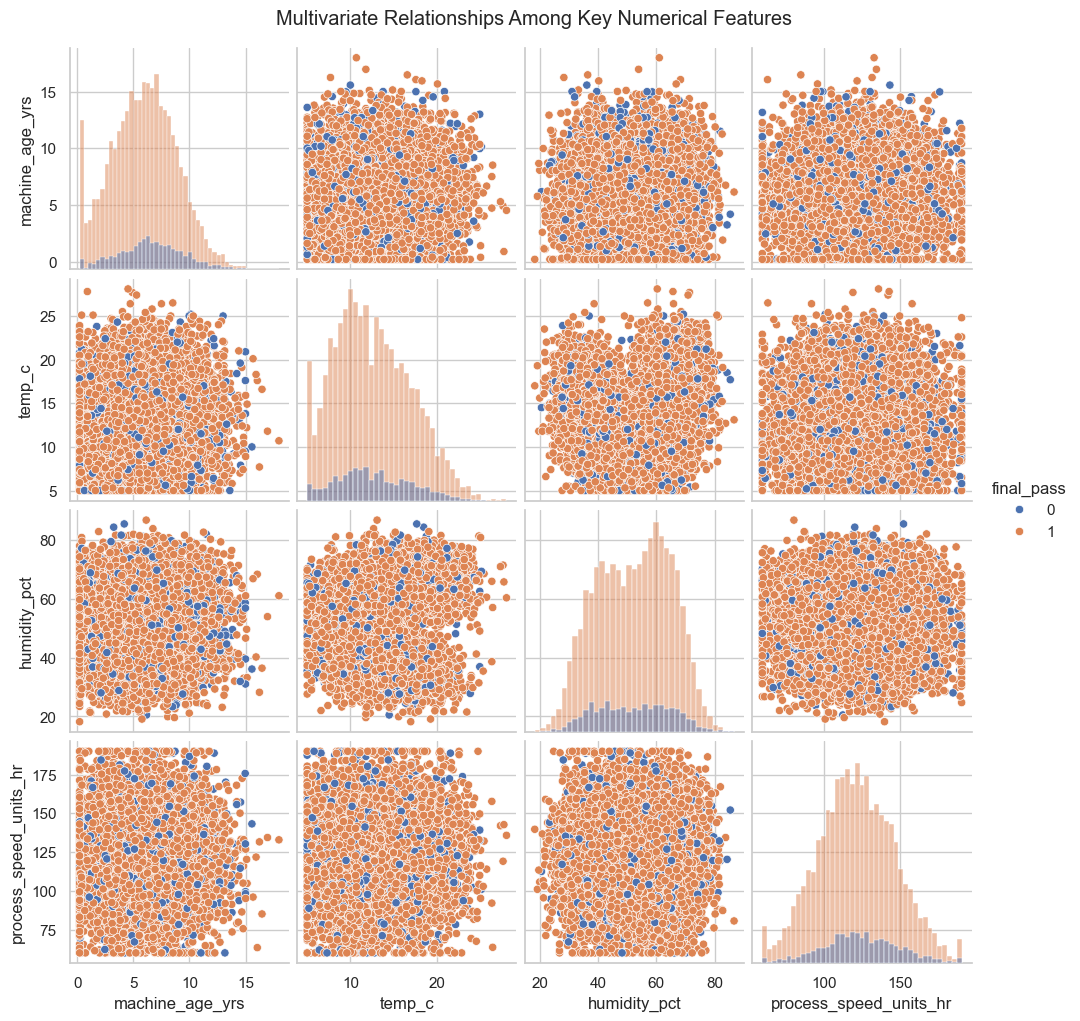

In [65]:
# =============================================================================
# Multivariate Numerical Analysis
# =============================================================================

pairplot_features = [
    "machine_age_yrs",
    "temp_c",
    "humidity_pct",
    "process_speed_units_hr",
    TARGET
]

pairplot_features = [
    feature for feature in pairplot_features
    if feature in df.columns
]

pairplot_df = df[pairplot_features].copy()

sns.pairplot(
    pairplot_df,
    hue=TARGET,
    diag_kind="hist"
)

plt.suptitle(
    "Multivariate Relationships Among Key Numerical Features",
    y=1.02
)

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "multivariate_pairplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
# =============================================================================
# Plant + Shift + Material Grade Analysis
# =============================================================================

three_way_analysis = (
    df.groupby(
        ["plant", "shift", "material_grade"]
    )[TARGET]
    .mean()
    .mul(100)
    .reset_index(name="Final Pass Rate")
    .sort_values(
        "Final Pass Rate",
        ascending=True
    )
)

display(three_way_analysis.head(10))

,plant,shift,material_grade,Final Pass Rate
5,plant_1,night,grade_C,80.60
22,plant_3,night,grade_B,83.85
17,plant_2,swing,grade_C,85.25
21,plant_3,night,grade_A,85.57
2,plant_1,day,grade_C,85.80
18,plant_3,day,grade_A,85.98
20,plant_3,day,grade_C,86.54
6,plant_1,swing,grade_A,86.60
4,plant_1,night,grade_B,86.75
11,plant_2,day,grade_C,86.86


In [67]:
# =============================================================================
# Save Multivariate Analysis Table
# =============================================================================

three_way_analysis.to_csv(
    os.path.join(
        TABLE_DIR,
        "plant_shift_material_pass_rate.csv"
    ),
    index=False
)

print("Multivariate analysis summary saved successfully.")

Multivariate analysis summary saved successfully.


## Insights

- Multivariate analysis shows that manufacturing quality can vary across combinations of operational factors rather than individual features alone.
- The combination of plant and shift reveals whether certain shifts consistently perform differently across production facilities.
- The combination of material grade and shift helps identify whether certain materials perform differently under specific operating conditions.
- The three-way analysis of plant, shift, and material grade helps identify specific operational combinations with relatively lower or higher final-pass rates.

### Business Insights

- Low-performing combinations can help identify specific operational conditions that may require further investigation.
- Comparing combinations rather than isolated features provides a more realistic view of manufacturing quality.
- These patterns can support targeted quality improvement rather than applying the same intervention across all plants or shifts.

### Feature Engineering Notes

- Important categorical interactions such as `plant + shift` or `material_grade + shift` may be considered as engineered features if they provide meaningful predictive information.
- We should not create every possible interaction automatically because this can increase model complexity.
- Any interaction features will be evaluated during Feature Engineering and validated using the training data.
- Multivariate relationships should be treated as associations rather than proof of causation.

# 3.15 Correlation Analysis

## Objective

In this section, we analyze the correlation between numerical features in the Manufacturing Quality Decisions dataset.

## Why are we doing this?

Correlation helps us understand whether numerical features have strong linear relationships with each other. Highly correlated features may contain overlapping information and can affect some machine learning models through multicollinearity.

Understanding these relationships also helps us identify potentially redundant features and useful variables for further analysis.

## What will we get?

We will calculate a correlation matrix and visualize it using a heatmap. We will also identify pairs of numerical features with relatively strong correlations.

**Summary:** Correlation analysis helps us understand relationships among numerical features and identify potentially redundant variables before Feature Engineering.

In [68]:
# =============================================================================
# 3.15 Correlation Analysis
# =============================================================================

# Select numerical features
correlation_df = df[numerical_features]

# Calculate correlation matrix
correlation_matrix = correlation_df.corr()

display(correlation_matrix.round(2))

,machine_age_yrs,temp_c,humidity_pct,process_speed_units_hr,defect_severity_0to3,decision_rework,rework_time_min,final_pass,scrap,total_cycle_time_min,energy_kwh,cost_usd,warranty_claim_90d
machine_age_yrs,1.00,0.00,-0.00,0.01,0.08,0.05,0.07,-0.07,0.05,0.07,0.06,0.07,0.01
temp_c,0.00,1.00,0.11,0.01,0.01,0.01,0.01,-0.01,-0.00,0.01,0.01,0.01,0.01
humidity_pct,-0.00,0.11,1.00,0.02,0.03,0.03,0.03,0.01,0.01,0.02,0.03,0.02,-0.01
process_speed_units_hr,0.01,0.01,0.02,1.00,0.08,0.03,0.06,-0.03,0.04,0.23,0.43,0.15,-0.02
defect_severity_0to3,0.08,0.01,0.03,0.08,1.00,0.54,0.84,-0.29,0.47,0.78,0.68,0.73,0.08
decision_rework,0.05,0.01,0.03,0.03,0.54,1.00,0.78,-0.07,0.20,0.72,0.61,0.51,-0.01
rework_time_min,0.07,0.01,0.03,0.06,0.84,0.78,1.00,-0.19,0.34,0.92,0.79,0.72,0.01
final_pass,-0.07,-0.01,0.01,-0.03,-0.29,-0.07,-0.19,1.00,-0.42,-0.17,-0.15,-0.38,-0.11
scrap,0.05,-0.00,0.01,0.04,0.47,0.20,0.34,-0.42,1.00,0.32,0.28,0.85,0.11
total_cycle_time_min,0.07,0.01,0.02,0.23,0.78,0.72,0.92,-0.17,0.32,1.00,0.90,0.74,0.01


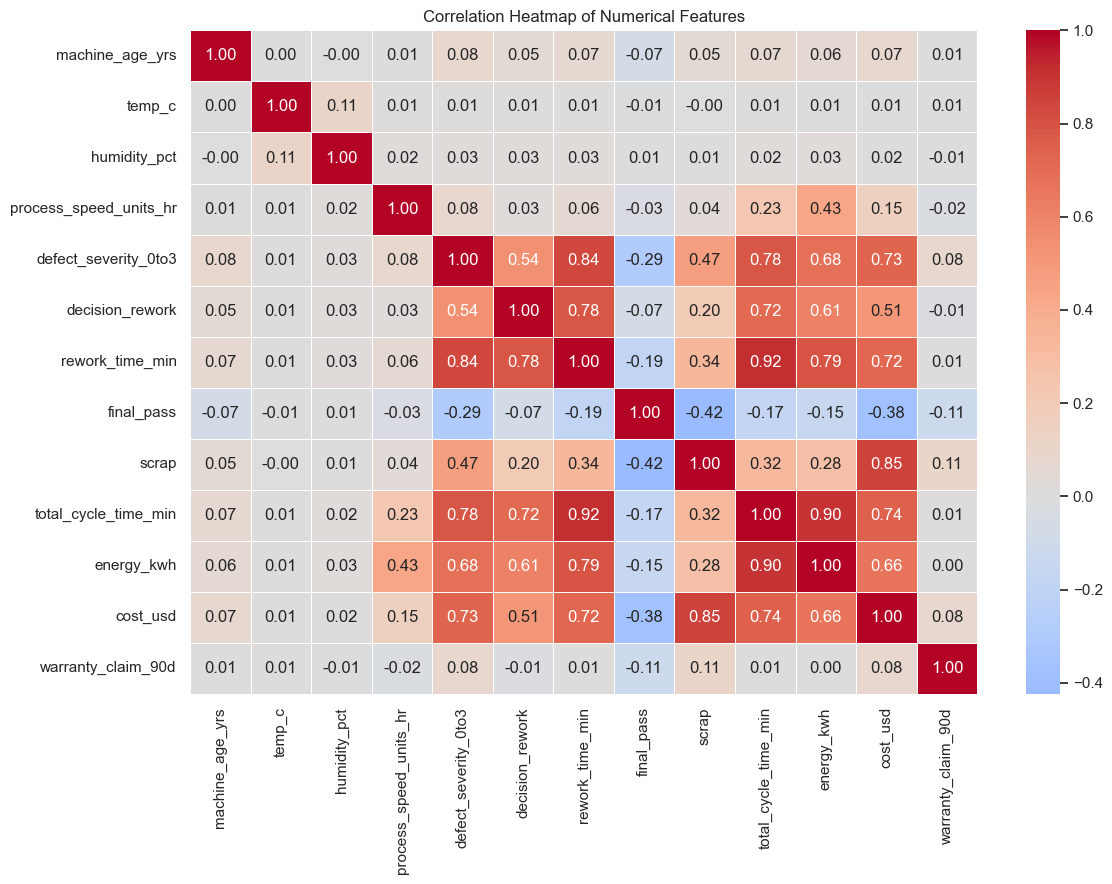

In [69]:
# =============================================================================
# Correlation Heatmap
# =============================================================================

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# =============================================================================
# Identify Strongly Correlated Feature Pairs
# =============================================================================

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

strong_correlations = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

# Calculate absolute correlation for ranking
strong_correlations["Absolute Correlation"] = (
    strong_correlations["Correlation"].abs()
)

# Show strongest relationships
strong_correlations = (
    strong_correlations
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

display(strong_correlations.head(15))

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,rework_time_min,total_cycle_time_min,0.92,0.92
1,total_cycle_time_min,energy_kwh,0.90,0.90
2,scrap,cost_usd,0.85,0.85
3,defect_severity_0to3,rework_time_min,0.84,0.84
4,rework_time_min,energy_kwh,0.79,0.79
5,decision_rework,rework_time_min,0.78,0.78
6,defect_severity_0to3,total_cycle_time_min,0.78,0.78
7,total_cycle_time_min,cost_usd,0.74,0.74
8,defect_severity_0to3,cost_usd,0.73,0.73
9,rework_time_min,cost_usd,0.72,0.72


In [71]:
# =============================================================================
# Strong Correlation Pairs
# =============================================================================

strong_pairs = strong_correlations[
    strong_correlations["Absolute Correlation"] >= 0.70
]

display(strong_pairs)

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,rework_time_min,total_cycle_time_min,0.92,0.92
1,total_cycle_time_min,energy_kwh,0.90,0.90
2,scrap,cost_usd,0.85,0.85
3,defect_severity_0to3,rework_time_min,0.84,0.84
4,rework_time_min,energy_kwh,0.79,0.79
5,decision_rework,rework_time_min,0.78,0.78
6,defect_severity_0to3,total_cycle_time_min,0.78,0.78
7,total_cycle_time_min,cost_usd,0.74,0.74
8,defect_severity_0to3,cost_usd,0.73,0.73
9,rework_time_min,cost_usd,0.72,0.72


In [72]:
# =============================================================================
# Save Correlation Results
# =============================================================================

correlation_matrix.to_csv(
    os.path.join(
        TABLE_DIR,
        "correlation_matrix.csv"
    )
)

strong_correlations.to_csv(
    os.path.join(
        TABLE_DIR,
        "strong_correlation_pairs.csv"
    ),
    index=False
)

print("Correlation analysis tables saved successfully.")

Correlation analysis tables saved successfully.


## Insights

- The correlation heatmap shows the strength and direction of relationships between numerical manufacturing features.
- The strongest positive relationship is between `rework_time_min` and `total_cycle_time_min`, with a correlation of approximately **0.92**.
- Several feature pairs show relatively high correlations, including `total_cycle_time_min` with `energy_kwh` (**0.90**) and `scrap` with `cost_usd` (**0.85**). These features may contain overlapping information and should be investigated further during Feature Engineering.
- Correlation measures linear association and does not establish causation.
- Low correlation does not necessarily mean that a feature is unimportant because non-linear relationships may still exist.

### Feature Engineering Notes

- Highly correlated features will not be removed automatically.
- Multicollinearity will be considered alongside model type, feature importance, and business meaning.
- Tree-based models are generally less sensitive to multicollinearity, while linear models can be more affected.
- The correlation analysis will help guide feature selection during Phase 4.

# 3.16 Outlier Analysis

## Objective

In this section, we identify potential outliers in the numerical manufacturing features using the Interquartile Range (IQR) method.

## Why are we doing this?

Extreme observations can affect statistical analysis and some machine learning algorithms. However, manufacturing outliers may represent genuine operating conditions, equipment issues, or unusual production events rather than incorrect data.

Therefore, we first identify and quantify potential outliers before deciding whether any treatment is necessary.

## What will we get?

We will calculate the number and percentage of potential outliers for each numerical feature and visualize their distribution using boxplots.

**Summary:** Outlier analysis helps us distinguish unusual observations from the normal operating range and provides information that will guide later preprocessing decisions.

In [73]:
# =============================================================================
# 3.16 Outlier Analysis
# =============================================================================

# Use numerical features only
outlier_summary = []

for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary = outlier_summary.round(2)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,machine_age_yrs,3.97,8.04,4.07,-2.13,14.14,38,0.38
1,temp_c,9.30,15.80,6.50,-0.45,25.55,8,0.08
2,humidity_pct,41.90,62.30,20.40,11.30,92.90,0,0.00
3,process_speed_units_hr,104.90,139.10,34.20,53.60,190.40,0,0.00
4,defect_severity_0to3,0.00,0.00,0.00,0.00,0.00,1597,15.97
5,decision_rework,0.00,0.00,0.00,0.00,0.00,2434,24.34
6,rework_time_min,0.00,0.00,0.00,0.00,0.00,2335,23.35
7,final_pass,1.00,1.00,0.00,1.00,1.00,1239,12.39
8,scrap,0.00,0.00,0.00,0.00,0.00,248,2.48
9,total_cycle_time_min,27.30,36.60,9.30,13.35,50.55,1042,10.42


In [74]:
# =============================================================================
# Rank Features by Outlier Percentage
# =============================================================================

outlier_ranking = (
    outlier_summary[
        ["Feature", "Outlier Count", "Outlier Percentage"]
    ]
    .sort_values(
        "Outlier Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(outlier_ranking)

,Feature,Outlier Count,Outlier Percentage
0,decision_rework,2434,24.34
1,rework_time_min,2335,23.35
2,defect_severity_0to3,1597,15.97
3,final_pass,1239,12.39
4,cost_usd,1047,10.47
5,total_cycle_time_min,1042,10.42
6,energy_kwh,593,5.93
7,scrap,248,2.48
8,warranty_claim_90d,125,1.25
9,machine_age_yrs,38,0.38


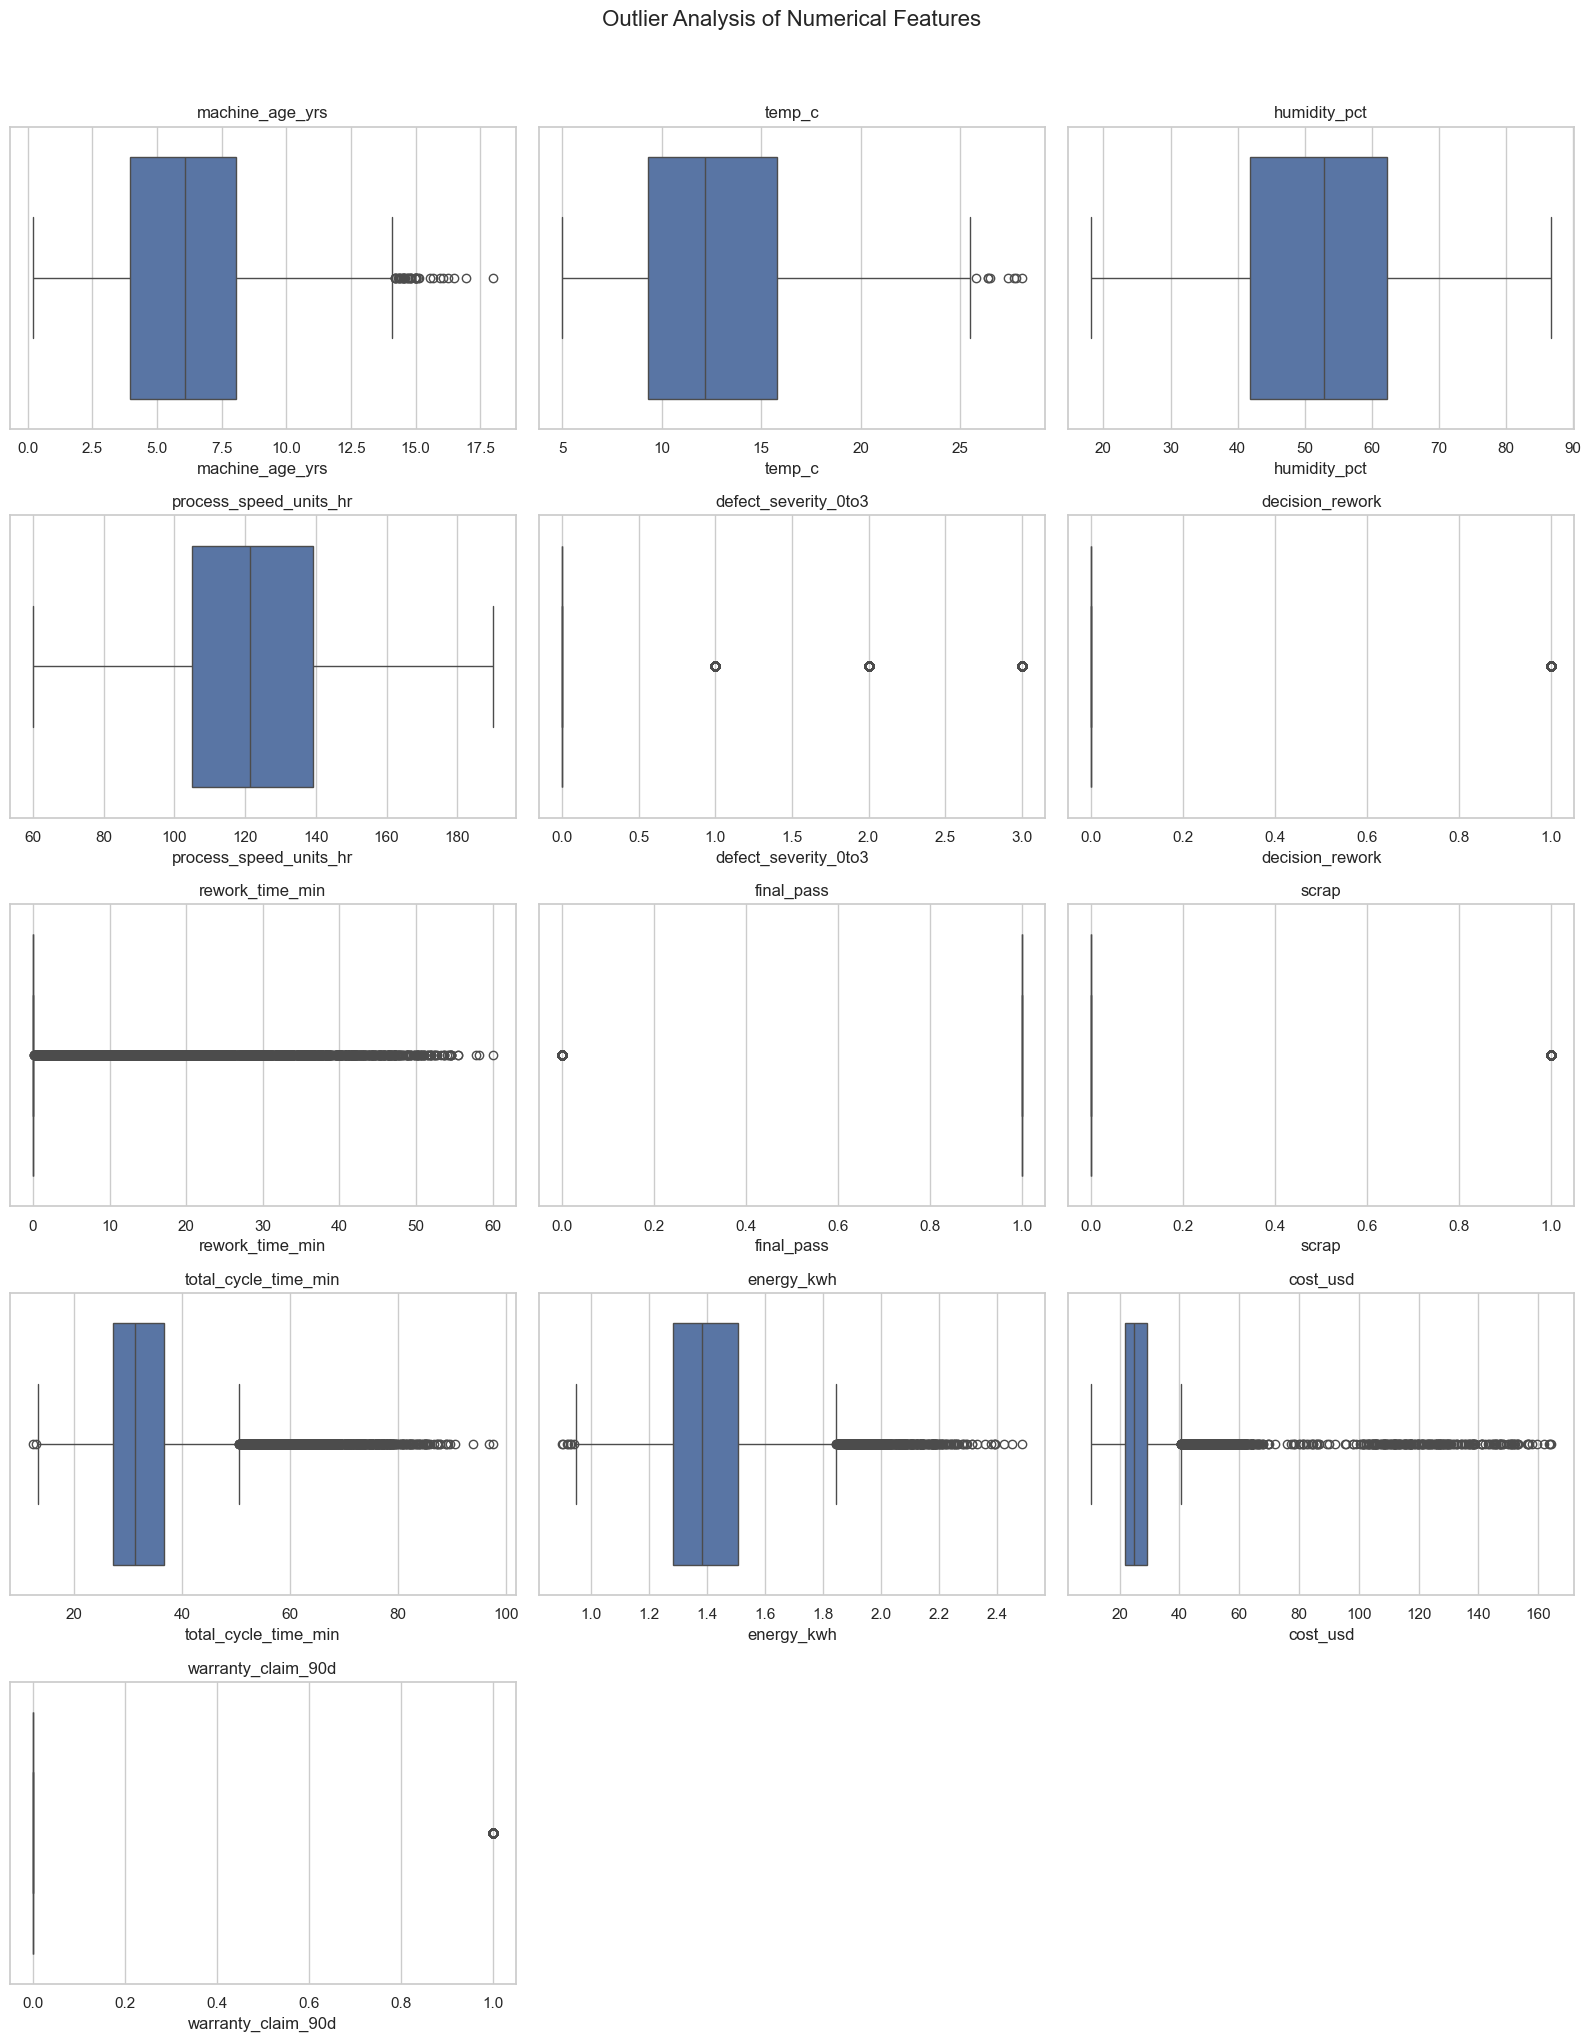

In [75]:
# =============================================================================
# Outlier Visualization
# =============================================================================

n_features = len(numerical_features)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x=feature,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel(feature)

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "Outlier Analysis of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save important figure
plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "outlier_analysis_boxplots.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
# =============================================================================
# Features with Relatively High Outlier Percentage
# =============================================================================

high_outlier_features = outlier_ranking[
    outlier_ranking["Outlier Percentage"] >= 5
]

print("Features with Outlier Percentage >= 5%:")

display(high_outlier_features)

Features with Outlier Percentage >= 5%:


,Feature,Outlier Count,Outlier Percentage
0,decision_rework,2434,24.34
1,rework_time_min,2335,23.35
2,defect_severity_0to3,1597,15.97
3,final_pass,1239,12.39
4,cost_usd,1047,10.47
5,total_cycle_time_min,1042,10.42
6,energy_kwh,593,5.93


In [77]:
# =============================================================================
# Save Outlier Analysis Tables
# =============================================================================

outlier_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "outlier_summary.csv"
    ),
    index=False
)

outlier_ranking.to_csv(
    os.path.join(
        TABLE_DIR,
        "outlier_ranking.csv"
    ),
    index=False
)

print("Outlier analysis tables saved successfully.")

Outlier analysis tables saved successfully.


## Insights

- Potential outliers were identified across several numerical manufacturing features using the IQR method.
- The IQR analysis identified potential extreme observations in several numerical features, with `cost_usd`, `total_cycle_time_min`, and `energy_kwh` showing noticeable outlier proportions.
- Some variables such as `decision_rework`, `final_pass`, and `scrap` are binary or highly zero-inflated, so their IQR-based "outliers" should not be interpreted as data errors.
- The presence of an IQR-based outlier does not necessarily indicate an incorrect observation.
- Some extreme values may represent genuine manufacturing conditions, equipment behavior, or unusual production events.

### Business Interpretation

Potentially extreme manufacturing measurements may indicate unusual operating conditions that could be useful for quality monitoring rather than simply being treated as errors.

### Feature Engineering Notes

- Outliers will not be automatically removed from the dataset.
- Features with substantial outlier presence will be investigated together with their business meaning and distribution.
- If required, robust scaling, transformation, capping, or other suitable treatment may be considered during Feature Engineering.
- Any outlier treatment will be applied carefully so that genuine manufacturing events are not incorrectly discarded.

# 3.17 Feature Distribution Analysis

## Objective

In this section, we analyze the distribution characteristics of numerical features, focusing on skewness, kurtosis, and the overall shape of the feature distributions.

## Why are we doing this?

Machine learning features can have highly skewed or unusually shaped distributions. Understanding these characteristics helps us determine whether transformations or robust preprocessing techniques may be useful during Feature Engineering.

## What will we get?

We will calculate skewness and kurtosis for the numerical features and visualize the distributions of features that show noticeable skewness.

**Summary:** Feature distribution analysis helps identify numerical variables that may require transformation or special preprocessing before model development.

In [78]:
# =============================================================================
# 3.17 Feature Distribution Analysis
# =============================================================================

distribution_summary = pd.DataFrame({
    "Feature": numerical_features,
    "Skewness": df[numerical_features].skew().values,
    "Kurtosis": df[numerical_features].kurtosis().values
})

distribution_summary["Absolute Skewness"] = (
    distribution_summary["Skewness"].abs()
)

distribution_summary = (
    distribution_summary
    .sort_values("Absolute Skewness", ascending=False)
    .reset_index(drop=True)
)

distribution_summary = distribution_summary.round(3)

display(distribution_summary)

,Feature,Skewness,Kurtosis,Absolute Skewness
0,warranty_claim_90d,8.78,75.05,8.78
1,scrap,6.11,35.37,6.11
2,cost_usd,4.42,23.09,4.42
3,defect_severity_0to3,2.50,5.14,2.50
4,rework_time_min,2.43,5.12,2.43
5,final_pass,-2.28,3.21,2.28
6,total_cycle_time_min,1.88,3.65,1.88
7,energy_kwh,1.22,2.02,1.22
8,decision_rework,1.20,-0.57,1.20
9,temp_c,0.36,-0.50,0.36


In [79]:
# =============================================================================
# Identify Noticeably Skewed Features
# =============================================================================

skewed_features = distribution_summary[
    distribution_summary["Absolute Skewness"] >= 1
]["Feature"].tolist()

print("Features with |Skewness| >= 1:")
print(skewed_features)

Features with |Skewness| >= 1:
['warranty_claim_90d', 'scrap', 'cost_usd', 'defect_severity_0to3', 'rework_time_min', 'final_pass', 'total_cycle_time_min', 'energy_kwh', 'decision_rework']


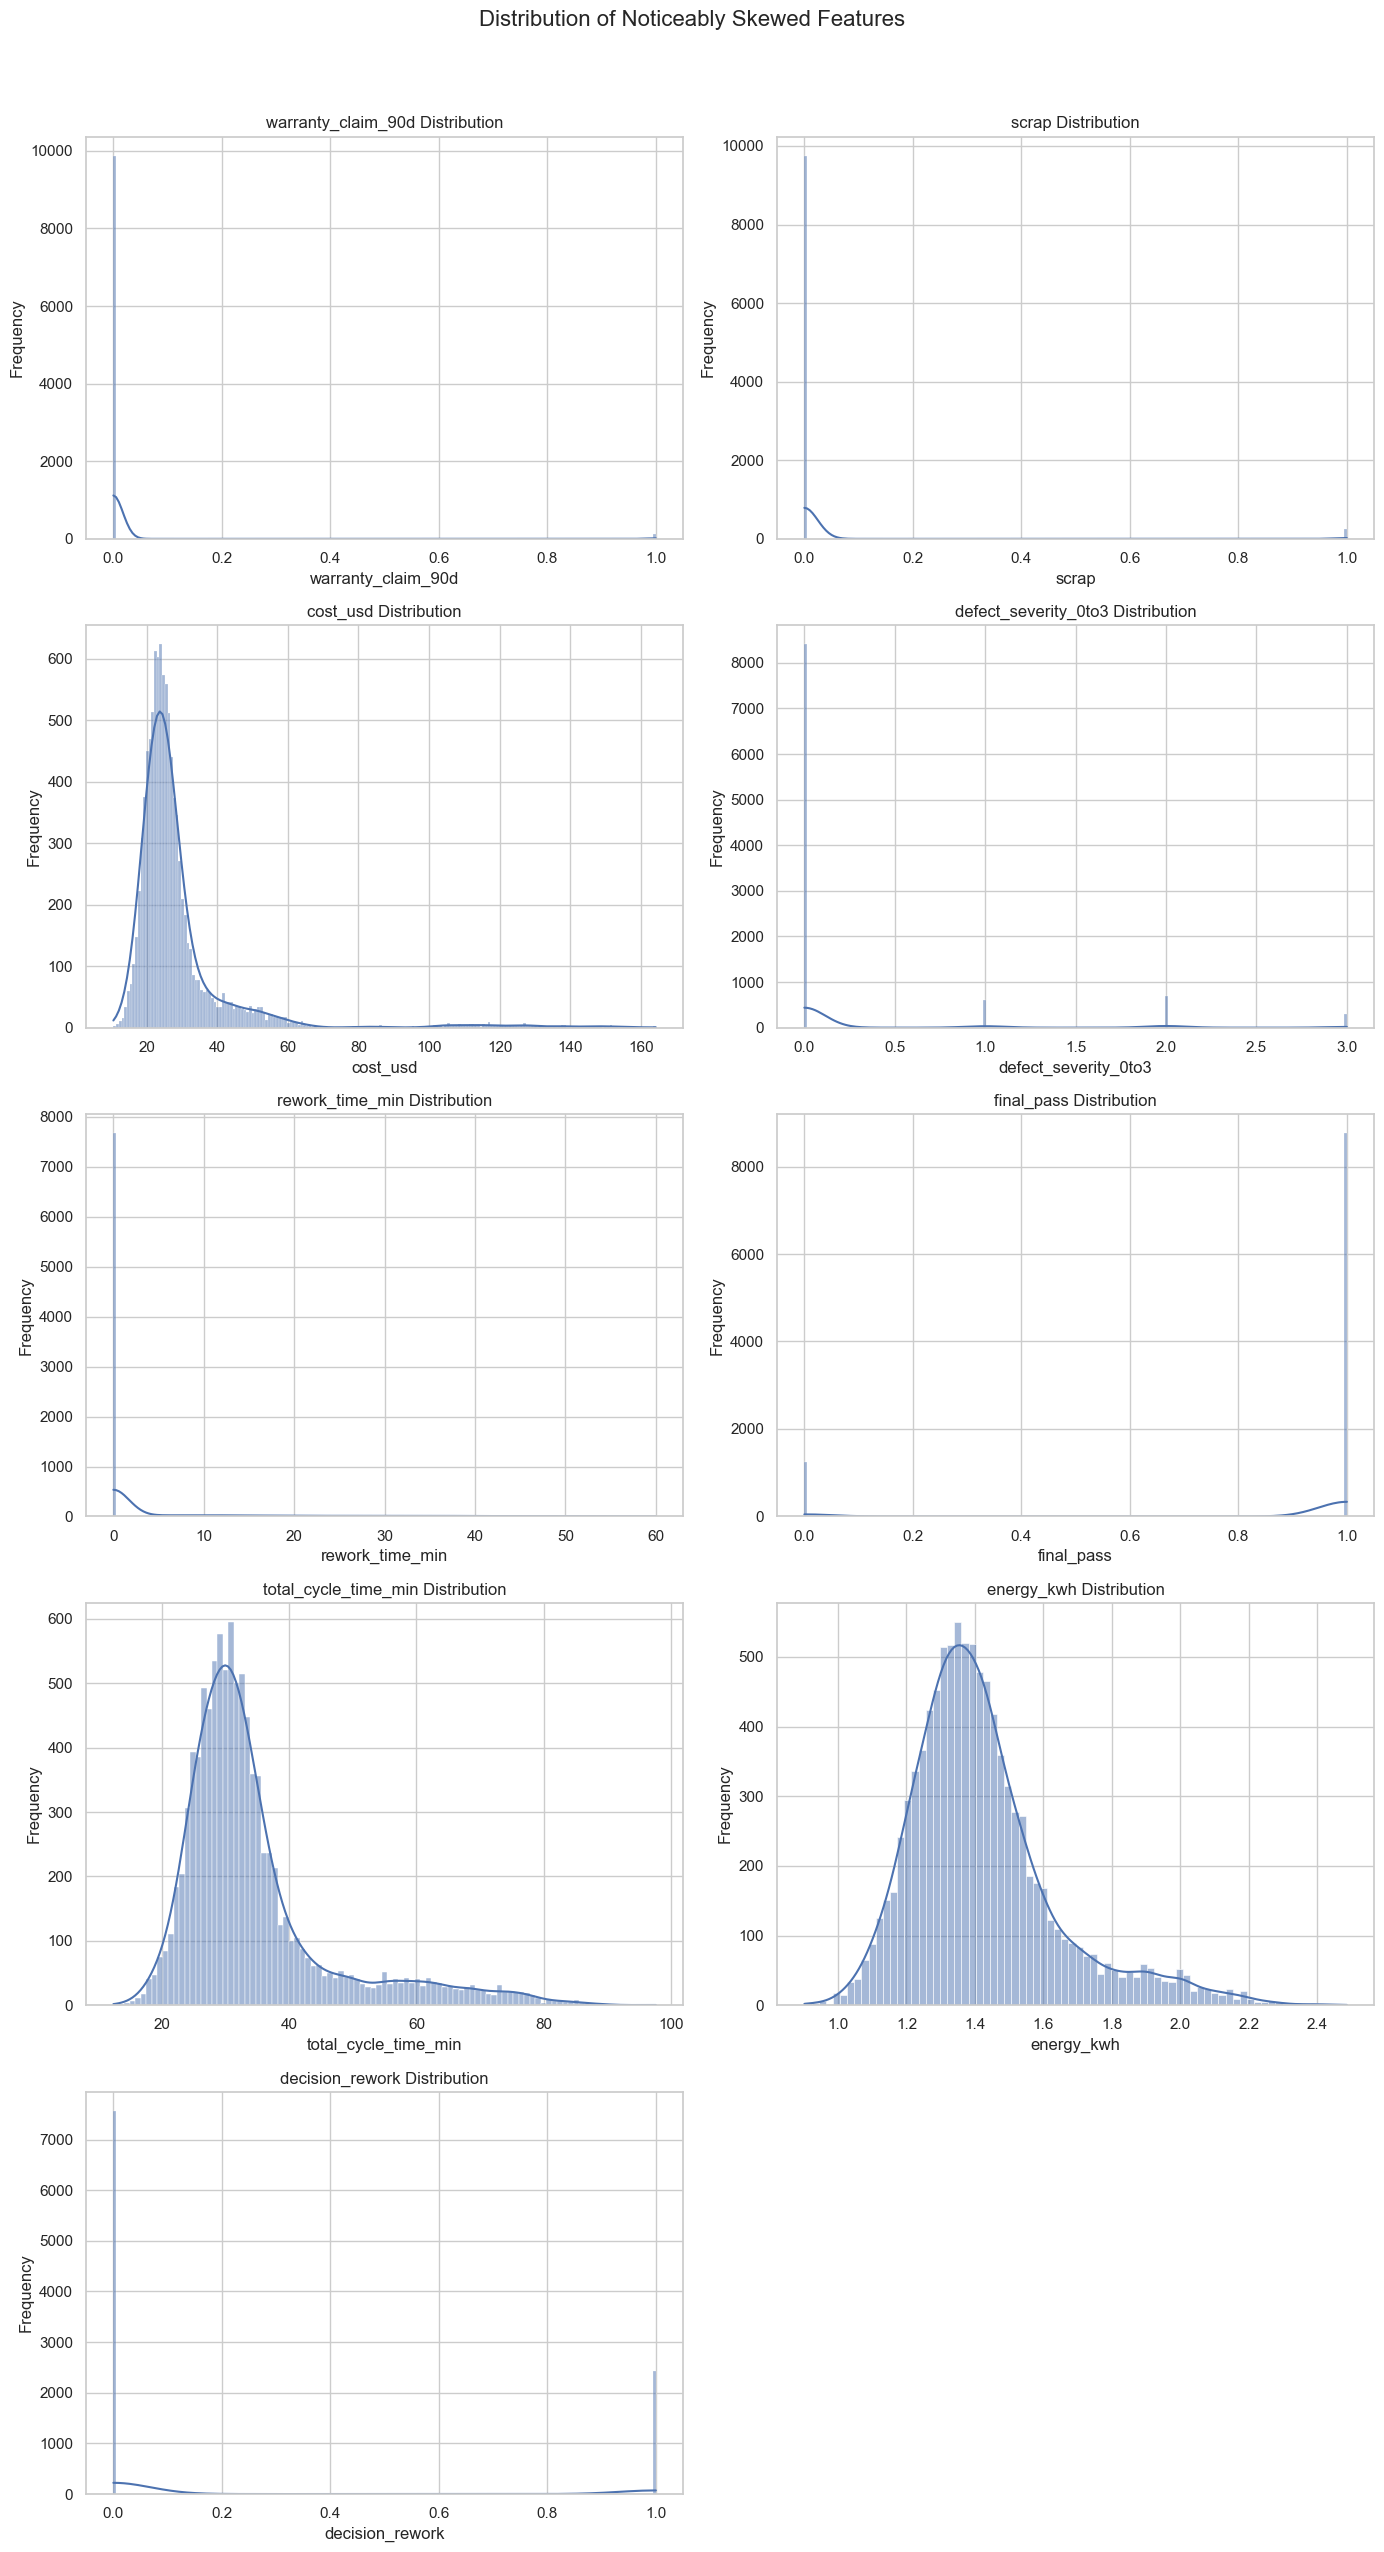

In [80]:
# =============================================================================
# Distribution of Skewed Features
# =============================================================================

if len(skewed_features) > 0:

    n_features = len(skewed_features)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(14, 5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(skewed_features):

        sns.histplot(
            data=df,
            x=feature,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(
            f"{feature} Distribution"
        )

        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")

    # Hide unused axes
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(
        "Distribution of Noticeably Skewed Features",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURE_DIR,
            "skewed_feature_distributions.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    print("No features meet the selected skewness threshold.")

In [81]:
# =============================================================================
# Save Feature Distribution Summary
# =============================================================================

distribution_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "feature_distribution_summary.csv"
    ),
    index=False
)

print("Feature distribution summary saved successfully.")

Feature distribution summary saved successfully.


## Insights

- The numerical features exhibit different distribution shapes across the manufacturing dataset.
- The most skewed feature is `warranty_claim_90d`, with a skewness of approximately **8.78**.
- **9 features** show noticeable skewness based on the selected screening threshold of |Skewness| >= 1.
- Highly skewed distributions are mainly associated with sparse or zero-inflated variables and may require additional investigation before selecting appropriate preprocessing techniques.
### Feature Engineering Notes

- Skewed features will not automatically be transformed.
- Transformation decisions will depend on the feature's business meaning and the requirements of the selected machine learning algorithms.
- Tree-based models generally do not require normally distributed features.
- If linear or distance-based models are used, appropriate transformations and scaling may become more important.
- Any required transformation will be implemented during Phase 4 Feature Engineering.

# 3.18 Business Insights

## Objective

In this section, we summarize the most important business and manufacturing insights discovered during the EDA.

## Why are we doing this?

EDA is not only about statistics and visualizations. The purpose is to understand the underlying business problem and identify patterns that can support better decision-making.

For FactoryGuard AI, the goal is to understand which manufacturing conditions, operational groups, and quality-related factors are associated with the final quality outcome.

## What will we get?

We will combine the important findings from the previous EDA sections into a concise set of manufacturing insights. These findings will help guide Feature Engineering and the later machine learning model.

**Summary:** Business insights translate the technical EDA results into actionable observations about manufacturing quality and provide direction for the predictive modeling stage.

In [82]:
# =============================================================================
# 3.18 Business Insights
# Overall Quality Performance
# =============================================================================

overall_pass_rate = df[TARGET].mean() * 100
overall_fail_rate = 100 - overall_pass_rate

business_summary = pd.DataFrame({
    "Metric": [
        "Total Production Records",
        "Final Pass Rate (%)",
        "Final Fail Rate (%)"
    ],
    "Value": [
        len(df),
        round(overall_pass_rate, 2),
        round(overall_fail_rate, 2)
    ]
})

display(business_summary)

,Metric,Value
0,Total Production Records,10000.00
1,Final Pass Rate (%),87.61
2,Final Fail Rate (%),12.39


In [83]:
# =============================================================================
# Plant Performance
# =============================================================================

plant_performance = (
    df.groupby("plant")[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

plant_performance["Pass Rate (%)"] = (
    plant_performance["mean"] * 100
).round(2)

plant_performance = plant_performance.drop(columns="mean")

plant_performance = plant_performance.sort_values(
    "Pass Rate (%)",
    ascending=False
)

display(plant_performance)

,plant,count,Pass Rate (%)
1,plant_2,3529,87.99
0,plant_1,4459,87.51
2,plant_3,2012,87.18


In [84]:
# =============================================================================
# Shift Performance
# =============================================================================

shift_performance = (
    df.groupby("shift")[TARGET]
    .agg(["count", "mean"])
    .reset_index()
)

shift_performance["Pass Rate (%)"] = (
    shift_performance["mean"] * 100
).round(2)

shift_performance = shift_performance.drop(columns="mean")

shift_performance = shift_performance.sort_values(
    "Pass Rate (%)",
    ascending=False
)

display(shift_performance)

,shift,count,Pass Rate (%)
0,day,4785,87.92
2,swing,3248,87.68
1,night,1967,86.73


In [85]:
# =============================================================================
# Plant + Shift Performance
# =============================================================================

plant_shift_performance = (
    df.groupby(["plant", "shift"])[TARGET]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="Pass Rate (%)")
    .sort_values("Pass Rate (%)", ascending=True)
)

display(plant_shift_performance)

,plant,shift,Pass Rate (%)
7,plant_3,night,85.64
1,plant_1,night,86.66
6,plant_3,day,86.73
2,plant_1,swing,87.06
4,plant_2,night,87.45
5,plant_2,swing,87.86
0,plant_1,day,88.17
3,plant_2,day,88.29
8,plant_3,swing,88.79


In [86]:
# =============================================================================
# Save Business Insight Tables
# =============================================================================

business_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "business_quality_summary.csv"
    ),
    index=False
)

plant_performance.to_csv(
    os.path.join(
        TABLE_DIR,
        "plant_performance.csv"
    ),
    index=False
)

shift_performance.to_csv(
    os.path.join(
        TABLE_DIR,
        "shift_performance.csv"
    ),
    index=False
)

plant_shift_performance.to_csv(
    os.path.join(
        TABLE_DIR,
        "plant_shift_performance.csv"
    ),
    index=False
)

print("Business insight tables saved successfully.")

Business insight tables saved successfully.


## Business Insights

### 1. Overall Quality Distribution

- The dataset contains approximately **10,000 manufacturing records**.
- The overall final-pass rate is approximately **87.61%**, while approximately **12.39%** of observations belong to the minority class.
- This indicates that unsuccessful quality outcomes are less frequent but still significant enough to require dedicated monitoring.

### 2. Manufacturing Conditions

- Numerical analysis shows that manufacturing variables such as temperature, humidity, process speed, cycle time, energy consumption, and cost have different distributions and levels of variability.
- Several variables show noticeable skewness or extreme observations, indicating that unusual operating conditions are present in the manufacturing process.

### 3. Relationships Between Manufacturing Variables

- `rework_time_min` and `total_cycle_time_min` show a very strong positive correlation of approximately **0.92**.
- `total_cycle_time_min` and `energy_kwh` also show a strong relationship of approximately **0.90**.
- These relationships suggest that some manufacturing measurements may contain overlapping information.

### 4. Operational Differences

- Pass rates vary across manufacturing groups such as plants, production lines, shifts, and material grades.
- The Plant + Shift analysis provides a more detailed view of operational combinations that may be associated with relatively higher or lower quality performance.
- These differences can help identify areas that may require further investigation.

### 5. Outliers and Unusual Observations

- Several continuous manufacturing variables contain potential extreme observations.
- These observations should not automatically be removed because they may represent genuine manufacturing events or unusual operating conditions.

### 6. Machine Learning Implications

- The target imbalance means that model evaluation should not rely only on accuracy.
- Precision, recall, F1-score, ROC-AUC, and the confusion matrix will be important during model evaluation.
- Highly correlated and potentially post-outcome variables will be carefully evaluated during Feature Engineering to avoid redundant information and target leakage.

### 7. Feature Engineering Direction

The EDA suggests that the next phase should focus on:

- Appropriate encoding of categorical features.
- Scaling of numerical features where required.
- Careful treatment of skewed numerical variables.
- Investigation of highly correlated features.
- Careful treatment of outliers.
- Removal of identifier or leakage-prone features where appropriate.
- Handling the target imbalance during model development.

# 3.19 EDA Summary

## Objective

In this section, we summarize the major findings from the complete Exploratory Data Analysis and document the decisions that will guide the Feature Engineering phase.

## Why are we doing this?

EDA produces many individual observations, but the final outcome should be a clear understanding of the dataset, its quality, important patterns, and potential modeling challenges.

This summary brings together the most important findings and creates a direct connection between EDA and the next phase of the project.

## What will we get?

We will summarize the dataset structure, target distribution, feature relationships, categorical patterns, outliers, skewness, correlation, potential target leakage, and the main preprocessing considerations identified during EDA.

**Summary:** The EDA summary provides the final technical and business understanding of the dataset and establishes the feature-engineering requirements for FactoryGuard AI.

In [87]:
# =============================================================================
# 3.19 EDA Summary
# Final Dataset Statistics
# =============================================================================

final_eda_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Numerical Features",
        "Categorical Features",
        "Missing Values",
        "Duplicate Records",
        "Final Pass Rate (%)",
        "Minority Class Rate (%)"
    ],
    "Value": [
        len(df),
        df.shape[1],
        len(numerical_features),
        len(categorical_features),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        round(df[TARGET].mean() * 100, 2),
        round(df[TARGET].value_counts(normalize=True).min() * 100, 2)
    ]
})

display(final_eda_summary)

,Metric,Value
0,Total Records,10000.00
1,Total Features,23.00
2,Numerical Features,13.00
3,Categorical Features,10.00
4,Missing Values,0.00
5,Duplicate Records,0.00
6,Final Pass Rate (%),87.61
7,Minority Class Rate (%),12.39


In [88]:
# =============================================================================
# Save Final EDA Summary
# =============================================================================

final_eda_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "final_eda_summary.csv"
    ),
    index=False
)

print("Final EDA summary saved successfully.")

Final EDA summary saved successfully.


## Final EDA Findings

### Dataset Quality

- The dataset contains approximately **10,000 manufacturing records** across multiple operational and process-related features.
- No significant missing-value issue was identified during the data-quality analysis.
- Duplicate records were checked as part of the EDA process.
- The dataset contains both numerical and categorical variables requiring different preprocessing approaches.

### Target Variable

- The target variable is `final_pass`.
- The target distribution is imbalanced, with approximately **87.61%** of observations belonging to the majority class and **12.39%** to the minority class.
- The majority-to-minority ratio is approximately **7.07:1**.
- Therefore, accuracy alone will not be sufficient for evaluating the final classification model.

### Numerical Features

- Manufacturing variables such as temperature, humidity, process speed, machine age, cycle time, energy consumption, and cost show different distributions and levels of variability.
- Several numerical variables contain potential extreme observations.
- Some variables also exhibit noticeable skewness, particularly variables with sparse or zero-inflated distributions.

### Correlation

- Strong correlations were identified between several numerical features.
- The strongest relationship was between `rework_time_min` and `total_cycle_time_min`, with a correlation of approximately **0.92**.
- `total_cycle_time_min` and `energy_kwh` also showed a strong correlation of approximately **0.90**.
- These relationships will be considered during Feature Engineering to avoid unnecessary redundancy.

### Categorical Features

- Operational variables such as plant, production line, shift, material grade, and inspection method show different category distributions.
- Differences in quality performance across these groups may provide useful predictive information.
- High-cardinality identifier variables such as `machine_id` and `operator_id` require additional consideration before modeling.

### Business Insights

- Manufacturing quality varies across different operational conditions and groups.
- Plant, shift, material, and process-related variables may contain useful information for predicting final quality.
- Multivariate analysis indicates that combinations of operational factors may provide more useful information than individual variables alone.

### Outlier and Distribution Findings

- Potential outliers were identified in several numerical features using the IQR method.
- Outliers will not automatically be removed because some extreme observations may represent genuine manufacturing events.
- Several features show noticeable skewness and will be evaluated during Feature Engineering before selecting any transformation.

### Data Leakage Consideration

- Some variables require careful investigation because they may represent information generated after or around the quality decision.
- Features such as `decision_rework`, `rework_time_min`, `scrap`, and `warranty_claim_90d` will therefore be evaluated for prediction-time availability before being included in the final model.
- This step is important to ensure that the model learns from information that would realistically be available when FactoryGuard makes a prediction.

## Feature Engineering Requirements

Based on the EDA, Phase 4 will focus on:

1. Identifying and removing inappropriate identifier or leakage-prone features.
2. Selecting the final predictive feature set.
3. Encoding categorical variables.
4. Scaling numerical variables where required.
5. Investigating appropriate treatment for skewed numerical features.
6. Evaluating the treatment of potential outliers.
7. Handling the target-class imbalance during model training.
8. Creating only meaningful engineered features and interactions.
9. Preparing the final dataset for machine learning.

## EDA Conclusion

The Exploratory Data Analysis provided a detailed understanding of the manufacturing dataset, its quality, target distribution, feature relationships, operational patterns, and potential modeling challenges.

The dataset is suitable for developing a classification-based manufacturing quality prediction system, provided that feature availability, target leakage, class imbalance, and appropriate preprocessing are carefully addressed.

The findings from this phase will now be used to build the final machine-learning-ready feature set in **Phase 4 — Feature Engineering**.

In [89]:
# =============================================================================
# Phase 3 Completion
# =============================================================================

print("=" * 70)
print("PHASE 3 - EXPLORATORY DATA ANALYSIS COMPLETED")
print("=" * 70)

print("Dataset structure       : Analyzed")
print("Data quality            : Analyzed")
print("Target distribution     : Analyzed")
print("Numerical features      : Analyzed")
print("Categorical features    : Analyzed")
print("Feature relationships   : Analyzed")
print("Correlation             : Analyzed")
print("Outliers                : Analyzed")
print("Feature distributions   : Analyzed")
print("Business insights       : Documented")
print("=" * 70)

print("Ready for Phase 4 - Feature Engineering")

PHASE 3 - EXPLORATORY DATA ANALYSIS COMPLETED
Dataset structure       : Analyzed
Data quality            : Analyzed
Target distribution     : Analyzed
Numerical features      : Analyzed
Categorical features    : Analyzed
Feature relationships   : Analyzed
Correlation             : Analyzed
Outliers                : Analyzed
Feature distributions   : Analyzed
Business insights       : Documented
Ready for Phase 4 - Feature Engineering
